In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot3 as uproot
#import uproot4 as uprootnew
import pandas as pd
import numpy as np
import math
from tqdm import tqdm

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

import kdar_functions as kdar
import general_functions as utils

import scipy.stats as stats

import os

import importlib



In [2]:
print(xgb.__version__)

2.1.4


In [3]:
single_run = False

In [4]:
importlib.reload(kdar)
importlib.reload(utils)

<module 'general_functions' from '/Users/bbogart/Documents/analysisCode/kdar_bdt/general_functions.py'>

In [5]:
def assign_bdt_vars(bdt_model,names,bdt_var):
    d_pred_df = kdar_overlay_df.fillna(0)[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    print(d_pred)
    kdar_overlay_df[bdt_var] = d_pred
    
    d_pred_df = train_kdar_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    train_kdar_df[bdt_var] = d_pred
    
    d_pred_df = train_lowE_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    train_lowE_df[bdt_var] = d_pred
    
    d_pred_df = train_overlay_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    train_overlay_df[bdt_var] = d_pred
    
    d_pred_df = train_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    train_df[bdt_var] = d_pred
    
    d_pred_df = test_kdar_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    test_kdar_df[bdt_var] = d_pred
    
    d_pred_df = test_lowE_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    test_lowE_df[bdt_var] = d_pred
    
    d_pred_df = test_overlay_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    test_overlay_df[bdt_var] = d_pred
    
    d_pred_df = test_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    test_df[bdt_var] = d_pred
    
    
    d_pred_df = nuwro_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    nuwro_df[bdt_var] = d_pred
    
    d_pred_df = train_nuwro_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    train_nuwro_df[bdt_var] = d_pred
    
    d_pred_df = test_nuwro_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    test_nuwro_df[bdt_var] = d_pred
    
    
    d_pred_df = gibuu_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    gibuu_df[bdt_var] = d_pred
    
    d_pred_df = train_gibuu_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    train_gibuu_df[bdt_var] = d_pred
    
    d_pred_df = test_gibuu_df[names]
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = bdt_model.predict(d_reg)
    test_gibuu_df[bdt_var] = d_pred

In [6]:
def evaluate_BDT(bdt_model,bdt_var,evals_result,max_items=10,split_horncur=True):

   
    bins = np.linspace(1e-7, 1, num=21)
      
    y_sig_test,x = np.histogram(test_df.query("is_KDAR==1")[bdt_var].to_numpy(),bins=bins,density=True)
    y_bck_test,x = np.histogram(test_df.query("is_KDAR==0")[bdt_var].to_numpy(),bins=bins,density=True)
    
    plt.figure()
    plt.hist(train_df.query("is_KDAR==1")[bdt_var].to_numpy(),bins=bins,density=True,alpha=0.8,color="dodgerblue",label="Train Sig")
    plt.plot(utils.get_bin_centers(x),y_sig_test,color="darkblue",marker="o",ms=6,lw=0,label="Test Sig")
    plt.hist(train_df.query("is_KDAR==0")[bdt_var].to_numpy(),bins=bins,density=True,alpha=0.5,color="red",label="Train Bckg",histtype="step",lw=2)
    plt.plot(utils.get_bin_centers(x),y_bck_test,marker="^",ms=7,lw=0,color="firebrick",label="Test Bckg")
    plt.legend()
    plt.xlim(0.005,1)
    plt.xlabel(bdt_var)
    plt.ylabel("Counts (Area Norm)")
    plt.show()

    if split_horncur:
        y_sig_test,x = np.histogram(test_df.query("is_KDAR==1")[bdt_var].to_numpy(),bins=bins,density=True)
        y_bck_fhc_test,x = np.histogram(test_df.query("is_KDAR==0").query("horncur=='FHC'")[bdt_var].to_numpy(),bins=bins,density=True)
        y_bck_rhc_test,x = np.histogram(test_df.query("is_KDAR==0").query("horncur=='RHC'")[bdt_var].to_numpy(),bins=bins,density=True)
        print(y_bck_rhc_test)
        plt.figure()
        plt.hist(train_df.query("is_KDAR==1")[bdt_var].to_numpy(),bins=bins,density=True,alpha=0.8,color="dodgerblue",label="Train Sig")
        plt.plot(utils.get_bin_centers(x),y_sig_test,color="darkblue",marker="o",ms=6,lw=0,label="Test Sig")
        plt.hist(train_df.query("is_KDAR==0").query("horncur=='FHC'")[bdt_var].to_numpy(),bins=bins,density=True,alpha=0.7,color="magenta",label="Train FHC Bckg",histtype="step",lw=2)
        plt.plot(utils.get_bin_centers(x),y_bck_fhc_test,marker="^",ms=7,lw=0,color="magenta",label="Test FHC Bckg")

        plt.hist(train_df.query("is_KDAR==0").query("horncur=='RHC'")[bdt_var].to_numpy(),bins=bins,density=True,alpha=0.7,color="orangered",label="Train RHC Bckg",histtype="step",ls='--',lw=2)
        plt.plot(utils.get_bin_centers(x),y_bck_rhc_test,marker="<",ms=7,lw=0,color="orangered",label="Test RHC Bckg")
        
        plt.legend()
        plt.xlim(0.005,1)
        plt.xlabel(bdt_var)
        plt.ylabel("Counts (Area Norm)")
        plt.show()
    

    bins = np.linspace(1e-7, 1, num=21)
      
    y_sig_test,x = np.histogram(test_kdar_df.query("is_KDAR==1")[bdt_var].to_numpy(),bins=bins,density=True,weights=test_kdar_df.query("is_KDAR==1")["net_weight"].to_numpy())
    y_nuwro_test,x = np.histogram(test_nuwro_df.query("is_KDAR==1")[bdt_var].to_numpy(),bins=bins,density=True,weights=test_nuwro_df.query("is_KDAR==1")["net_weight"].to_numpy())
    y_gibuu_test,x = np.histogram(test_gibuu_df.query("is_KDAR==1")[bdt_var].to_numpy(),bins=bins,density=True,weights=test_gibuu_df.query("is_KDAR==1")["net_weight"].to_numpy())
    y_bck_test,x = np.histogram(test_df.query("is_KDAR==0")[bdt_var].to_numpy(),bins=bins,density=True,weights=test_df.query("is_KDAR==0")["net_weight"].to_numpy())
    
    plt.figure()
    plt.plot(utils.get_bin_centers(x),y_sig_test,color="green",marker="o",ms=8,lw=0,label="Test GENIE")
    plt.plot(utils.get_bin_centers(x),y_nuwro_test,color="orange",marker=">",ms=8,lw=0,label="Test NuWro")
    plt.plot(utils.get_bin_centers(x),y_gibuu_test,color="darkblue",marker="<",ms=8,lw=0,label="Test GiBUU")
    plt.plot(utils.get_bin_centers(x),y_bck_test,marker="^",ms=8,lw=0,color="firebrick",label="Test Bckg")
    plt.legend()
    plt.xlim(0.005,1)
    plt.xlabel("KDAR Score")
    plt.ylabel("Counts (Area Norm)")
    plt.show()


    

    importance = bdt_model.get_score(importance_type='gain')
    full_lists = sorted(importance.items(), key=lambda x: x[1]) 
    if(len(full_lists)>max_items): lists = full_lists[len(full_lists)-max_items:]
    else: lists = full_lists
    
    x, y = zip(*lists) # unpack a list of pairs into two tuples
    plt.title("Top Vars: Gain")
    plt.barh(x,y)
    plt.show()

    importance = bdt_model.get_score(importance_type='total_gain')
    full_lists = sorted(importance.items(), key=lambda x: x[1]) 
    if(len(full_lists)>max_items): lists = full_lists[len(full_lists)-max_items:]
    else: lists = full_lists    
    x, y = zip(*lists) # unpack a list of pairs into two tuples
    plt.title("Top Vars: Total Gain")
    plt.barh(x,y)
    plt.show()
    
    

    x = np.linspace(1,n,n)
    plt.figure()
    plt.plot(evals_result['train']['logloss'],label='train')
    plt.plot(evals_result['validation']['logloss'],label='test',ls='--')
    plt.ylim(0,1.1*np.max([np.max(evals_result['validation']['logloss']),np.max(evals_result['train']['logloss'])]))
    plt.ylabel("logloss")
    plt.xlabel("Round")
    plt.legend()
    plt.show()


    adjust_kdar_eff = 1
    
    preds = test_df[bdt_var].to_numpy()
    
    cut_values = np.geomspace(1e-3, 1, num=100)
    eff_vec=[]
    pur_vec=[]
    effpur_vec=[]
    effpurpur_vec=[]
    effeffpur_vec=[]

    is_KDAR = test_df["is_KDAR"].to_numpy()
    weights = test_df["net_weight"].to_numpy()
    
    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sel=0
        n_sig_sel=0
        n_bck_selg_sel=0
        for i in range(len(is_KDAR)):
            select=0
            if preds[i]>cut: 
                select=1
                n_sel+=weights[i]
            if is_KDAR[i]==1: 
                n_sig+=weights[i]
                if select==1:n_sig_sel+=weights[i]
        eff_vec.append(n_sig_sel/n_sig*adjust_kdar_eff)
        if n_sel==0: 
            pur_vec.append(0)
            effpur_vec.append(0)
            effpurpur_vec.append(0)
            effeffpur_vec.append(0)
        else: 
            pur_vec.append(n_sig_sel/n_sel)
            effpur_vec.append( (n_sig_sel/n_sig*adjust_kdar_eff) * (n_sig_sel/n_sel) )
            effpurpur_vec.append( (n_sig_sel/n_sig*adjust_kdar_eff) * (n_sig_sel/n_sel) * (n_sig_sel/n_sel) )
            effeffpur_vec.append( (n_sig_sel/n_sig*adjust_kdar_eff) * (n_sig_sel/n_sig*adjust_kdar_eff) * (n_sig_sel/n_sel) )


    preds = test_kdar_df[bdt_var].to_numpy()
    
    cut_values = np.geomspace(1e-3, 1, num=100)
    eff_vec_genie=[]

    is_KDAR = test_kdar_df["is_KDAR"].to_numpy()
    weights = test_kdar_df["net_weight"].to_numpy()
    
    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sig_sel=0
        for i in range(len(is_KDAR)):
            n_sig+=weights[i]
            if preds[i]>cut: 
                n_sig_sel+=weights[i]
        eff_vec_genie.append(n_sig_sel/n_sig*adjust_kdar_eff)

    preds = test_nuwro_df[bdt_var].to_numpy()
    
    cut_values = np.geomspace(1e-3, 1, num=100)
    eff_vec_nuwro=[]

    is_KDAR = test_nuwro_df["is_KDAR"].to_numpy()
    weights = test_nuwro_df["net_weight"].to_numpy()
    
    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sig_sel=0
        for i in range(len(is_KDAR)):
            n_sig+=weights[i]
            if preds[i]>cut: 
                n_sig_sel+=weights[i]
        eff_vec_nuwro.append(n_sig_sel/n_sig*adjust_kdar_eff)


    preds = test_gibuu_df[bdt_var].to_numpy()
    
    cut_values = np.geomspace(1e-3, 1, num=100)
    eff_vec_gibuu=[]

    is_KDAR = test_gibuu_df["is_KDAR"].to_numpy()
    weights = test_gibuu_df["net_weight"].to_numpy()
    
    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sig_sel=0
        for i in range(len(is_KDAR)):
            n_sig+=weights[i]
            if preds[i]>cut: 
                n_sig_sel+=weights[i]
        eff_vec_gibuu.append(n_sig_sel/n_sig*adjust_kdar_eff)
    
    preds = train_df[bdt_var].to_numpy()
    train_eff_vec=[]
    train_pur_vec=[]
    train_effpur_vec=[]
    train_effpurpur_vec=[]
    train_effeffpur_vec=[]
    
    is_KDAR = train_df["is_KDAR"].to_numpy()
    weights = train_df["net_weight"].to_numpy()

    for j in range(len(cut_values)):
        cut = cut_values[j]
        train_n_sig=0
        train_n_sel=0
        train_n_sig_sel=0
        train_n_bck_selg_sel=0
        for i in range(len(is_KDAR)):
            select=0
            if preds[i]>cut: 
                select=1
                train_n_sel+=weights[i]
            if is_KDAR[i]==1: 
                train_n_sig+=weights[i]
                if select==1:train_n_sig_sel+=weights[i]
        train_eff_vec.append(train_n_sig_sel/train_n_sig*adjust_kdar_eff)
        if train_n_sel==0: 
            train_pur_vec.append(0)
            train_effpur_vec.append(0)
            train_effpurpur_vec.append(0)
            train_effeffpur_vec.append(0)
        else: 
            train_pur_vec.append(train_n_sig_sel/train_n_sel)
            train_effpur_vec.append( (train_n_sig_sel/train_n_sig*adjust_kdar_eff) * (train_n_sig_sel/train_n_sel) )
            train_effpurpur_vec.append( (train_n_sig_sel/train_n_sig*adjust_kdar_eff) * (train_n_sig_sel/train_n_sel) * (train_n_sig_sel/train_n_sel) )
            train_effeffpur_vec.append( (train_n_sig_sel/train_n_sig*adjust_kdar_eff) * (train_n_sig_sel/train_n_sig*adjust_kdar_eff) * (train_n_sig_sel/train_n_sel) )
            
    
    preds = train_kdar_df[bdt_var].to_numpy()
    
    cut_values = np.geomspace(1e-3, 1, num=100)
    train_eff_vec_genie=[]

    is_KDAR = train_kdar_df["is_KDAR"].to_numpy()
    weights = train_kdar_df["net_weight"].to_numpy()
    
    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sig_sel=0
        for i in range(len(is_KDAR)):
            n_sig+=weights[i]
            if preds[i]>cut: 
                n_sig_sel+=weights[i]
        train_eff_vec_genie.append(n_sig_sel/n_sig*adjust_kdar_eff)

    preds = train_nuwro_df[bdt_var].to_numpy()
    
    cut_values = np.geomspace(1e-3, 1, num=100)
    train_eff_vec_nuwro=[]

    is_KDAR = train_nuwro_df["is_KDAR"].to_numpy()
    weights = train_nuwro_df["net_weight"].to_numpy()
    
    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sig_sel=0
        for i in range(len(is_KDAR)):
            n_sig+=weights[i]
            if preds[i]>cut: 
                n_sig_sel+=weights[i]
        train_eff_vec_nuwro.append(n_sig_sel/n_sig*adjust_kdar_eff)


    preds = train_gibuu_df[bdt_var].to_numpy()
    
    cut_values = np.geomspace(1e-3, 1, num=100)
    train_eff_vec_gibuu=[]

    is_KDAR = train_gibuu_df["is_KDAR"].to_numpy()
    weights = train_gibuu_df["net_weight"].to_numpy()
    
    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sig_sel=0
        for i in range(len(is_KDAR)):
            n_sig+=weights[i]
            if preds[i]>cut: 
                n_sig_sel+=weights[i]
        train_eff_vec_gibuu.append(n_sig_sel/n_sig*adjust_kdar_eff)


    
    plt.figure() 
    plt.plot(cut_values,eff_vec,label="Efficiency: Test",color='dodgerblue',lw=2)
    plt.plot(cut_values,pur_vec,label="Purity: Test",color='orange',lw=2)
    plt.plot(cut_values,train_eff_vec,label="Efficiency: Train",color='blue',ls=":",lw=2)
    plt.plot(cut_values,train_pur_vec,label="Purity: Train",color='orangered',ls=":",lw=2)
    plt.legend()
    plt.show()
    
    plt.figure() 
    plt.plot(cut_values,eff_vec_genie,label="GENIE: Test",color='darkgrey',lw=2)
    plt.plot(cut_values,train_eff_vec_genie,label="GENIE: Train",color='black',ls=":",lw=2)    
    plt.plot(cut_values,eff_vec_nuwro,label="NuWro: Test",color='red',lw=2)
    plt.plot(cut_values,train_eff_vec_nuwro,label="NuWro: Train",color='firebrick',ls=":",lw=2)    
    plt.plot(cut_values,eff_vec_gibuu,label="GiBUU: Test",color='dodgerblue',lw=2)
    plt.plot(cut_values,train_eff_vec_gibuu,label="GiBUU: Train",color='blue',ls=":",lw=2)  
    plt.legend()
    plt.show() 

    
    plt.figure() 
    plt.plot(cut_values,eff_vec,label="Eff*Pur: Test",color='dodgerblue',lw=2)
    plt.plot(cut_values,effpurpur_vec,label="Eff*Pur*Pur: Test",color='orange',lw=2)
    plt.plot(cut_values,effeffpur_vec,label="Eff*Eff*Pur: Test",color='lime',lw=2)
    plt.plot(cut_values,train_effpur_vec,label="Eff*Pur: Train",color='blue',ls=":",lw=2)
    plt.plot(cut_values,train_effpurpur_vec,label="Eff*Pur*Pur: Train",color='orangered',ls=":",lw=2)
    plt.plot(cut_values,train_effeffpur_vec,label="Eff*Eff*Pur: Train",color='green',ls=':',lw=2)
    plt.legend()
    plt.show()


    adjust_ext_eff = 1
    adjust_bck_eff = 1

    cut_values = np.geomspace(1e-3, 1, num=100)
    cut_values = np.linspace(1e-3, 1, num=300)
    test_sig_sqrt_bck_vec=[]
    test_sig_bck_vec=[]
    test_sig_bck_bck_vec=[]
    test_sig_per_vec=[]
    test_eff = []
    test_bck_eff=[]
    test_bck_nu_eff=[]
    test_bck_ext_eff=[]
    
    is_KDAR = test_df["is_KDAR"].to_numpy()
    isEXT = test_df["isEXT"].to_numpy()
    weights = np.ones_like(test_df["is_KDAR"].to_numpy())
    preds = test_df[bdt_var].to_numpy()

    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sel=0
        n_sig_sel=0
        n_bck_sel=0
        n_bck_nu_sel=0
        n_bck_ext_sel=0
        n_bck_nu=0
        n_bck_ext=1
        for i in range(len(is_KDAR)):
            select=0
            if preds[i]>cut: 
                select=1
                n_sel+=weights[i]
            if is_KDAR[i]==1: 
                n_sig+=weights[i]
                if select==1:n_sig_sel+=weights[i]
            else:
                if select: n_bck_sel+=weights[i]
                if isEXT[i]==1: 
                    n_bck_ext+=weights[i]
                    if select: n_bck_ext_sel+=weights[i]
                else: 
                    n_bck_nu+=weights[i]
                    if select: n_bck_nu_sel+=weights[i]
        n_bck = np.sum(weights)-n_sel
        if n_bck_sel==0: 
            test_sig_sqrt_bck_vec.append(0)
            test_sig_bck_vec.append(0)
            test_sig_bck_bck_vec.append(0)
            test_sig_per_vec.append(0)
        else: 
            test_sig_sqrt_bck_vec.append(n_sig_sel/np.sqrt(n_bck_sel))
            test_sig_bck_vec.append(n_sig_sel/n_bck_sel)
            test_sig_bck_bck_vec.append(n_sig_sel/n_bck_sel/n_bck_sel)
            test_sig_per_vec.append(n_sig_sel/np.sqrt(n_sig_sel+n_bck_sel))
        test_eff.append(n_sig_sel/n_sig*adjust_kdar_eff)
        test_bck_eff.append(n_bck_sel/(n_bck_ext*adjust_ext_eff+n_bck_nu*adjust_bck_eff))
        test_bck_nu_eff.append(n_bck_nu_sel/n_bck_nu*adjust_bck_eff)
        test_bck_ext_eff.append(n_bck_ext_sel/n_bck_ext*adjust_ext_eff)


    train_sig_sqrt_bck_vec=[]
    train_sig_bck_vec=[]
    train_sig_bck_bck_vec=[]
    train_sig_per_vec=[]
    train_eff = []
    train_bck_eff = []
    train_bck_nu_eff = []
    train_bck_ext_eff = []

    is_KDAR = train_df["is_KDAR"].to_numpy()
    isEXT = train_df["isEXT"].to_numpy()
    weights = np.ones_like(train_df["is_KDAR"].to_numpy())
    preds = train_df[bdt_var].to_numpy()
    
    for j in range(len(cut_values)):
        cut = cut_values[j]
        n_sig=0
        n_sel=0
        n_sig_sel=0
        n_bck_sel=0
        n_bck_nu_sel=0
        n_bck_ext_sel=0
        n_bck_nu=0
        n_bck_ext=1
        for i in range(len(is_KDAR)):
            select=0
            if preds[i]>cut: 
                select=1
                n_sel+=weights[i]
            if is_KDAR[i]==1: 
                n_sig+=weights[i]
                if select==1:n_sig_sel+=weights[i]
            else:
                if select: n_bck_sel+=weights[i]
                if isEXT[i]==1: 
                    n_bck_ext+=weights[i]
                    if select: n_bck_ext_sel+=weights[i]
                else: 
                    n_bck_nu+=weights[i]
                    if select: n_bck_nu_sel+=weights[i]
        n_bck = np.sum(weights)-n_sig
        if n_bck_sel==0: 
            train_sig_sqrt_bck_vec.append(0)
            train_sig_bck_vec.append(0)
            train_sig_bck_bck_vec.append(0)
            train_sig_per_vec.append(0)
        else: 
            train_sig_sqrt_bck_vec.append(n_sig_sel/np.sqrt(n_bck_sel))
            train_sig_bck_vec.append(n_sig_sel/n_bck_sel)
            train_sig_bck_bck_vec.append(n_sig_sel/n_bck_sel/n_bck_sel)
            train_sig_per_vec.append(n_sig_sel/np.sqrt(n_sig_sel+n_bck_sel))
        train_eff.append(n_sig_sel/n_sig*adjust_kdar_eff)
        train_bck_eff.append(n_bck_sel/n_bck*adjust_bck_eff)
        train_bck_eff.append(n_bck_sel/(n_bck_ext*adjust_ext_eff+n_bck_nu*adjust_bck_eff))
        train_bck_nu_eff.append(n_bck_nu_sel/n_bck_nu*adjust_bck_eff)
        train_bck_ext_eff.append(n_bck_ext_sel/n_bck_ext*adjust_ext_eff)
    
    
    plt.figure() 
    plt.plot(cut_values,test_eff,label="Sig Eff: Test",color='dodgerblue',lw=2)
    plt.plot(cut_values,test_bck_nu_eff,label="Bck nu Eff: Test",color='orange',lw=2)
    plt.plot(cut_values,train_eff,label="Sig Eff: Train",color='blue',ls=":",lw=2)
    plt.plot(cut_values,train_bck_nu_eff,label="Bck nu Eff: Train",color='darkorange',ls=":",lw=2)
    plt.legend()
    plt.show()




In [7]:
def plot_efficiency_detailed(bdt_var,cutvalue,no_gibuu_weights=True,wrt_preset=False,add_cut="",adjusty=False):
    
    truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
    xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]
    bins_list = []
    bins_list.append(np.linspace(0,130,14))
    bins_list.append(np.linspace(0,180,10))
    bins_list.append(np.linspace(0,130,14))
    bins_list.append(np.linspace(0,180,10))
    bins_list.append(np.linspace(-20,100,13))
    bins_list.append(np.linspace(50,450,11))
    bins_list.append(np.linspace(0,460,14))
    bins_list.append(np.linspace(0,130,14))
    bins_list.append(np.linspace(-200,200,21))
    bins_list.append(np.linspace(0,200,11))
    bins_list.append(np.linspace(0,150,16))
    bins_list.append(np.linspace(0,130,2))

    sig_query = "is_KDAR==1"
    if wrt_preset: sig_query = "is_KDAR==1 and "+kdar.presel_query
    
    sig_test_df = kdar_overlay_df.query(sig_query).copy()
    sig_sel_test_df = kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query(bdt_var+f">{cutvalue}").copy()
    if add_cut!="": sig_sel_test_df = sig_sel_test_df.query(add_cut)
    
    sig_nuwro_df = nuwro_df.query(sig_query).copy()
    sig_sel_nuwro_df = nuwro_df.query("is_KDAR==1").query(kdar.presel_query).copy().query(bdt_var+f">{cutvalue}").copy()
    if add_cut!="": sig_sel_nuwro_df = sig_sel_nuwro_df.query(add_cut)
    
    sig_gibuu_df = gibuu_df.query(sig_query).copy()
    sig_sel_gibuu_df = gibuu_df.query("is_KDAR==1").query(kdar.presel_query).copy().query(bdt_var+f">{cutvalue}").copy()
    if add_cut!="": sig_sel_gibuu_df = sig_sel_gibuu_df.query(add_cut)
    
    presel_eff = []
    nuwro_presel_eff = []
    gibuu_presel_eff = []
    
    for i in range(len(truth_vars)):
        
        var = truth_vars[i]
        bins = bins_list[i]
        test_sig, x = np.histogram( np.clip(sig_test_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_test_df['net_weight'].to_numpy())
        test_sig_sel, x = np.histogram( np.clip(sig_sel_test_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_test_df['net_weight'].to_numpy())
        nuwro_sig, x = np.histogram( np.clip(sig_nuwro_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_nuwro_df['net_weight'].to_numpy())
        nuwro_sig_sel, x = np.histogram( np.clip(sig_sel_nuwro_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_nuwro_df['net_weight'].to_numpy())
        gibuu_sig, x = np.histogram( np.clip(sig_gibuu_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_gibuu_df['net_weight'].to_numpy())
        gibuu_sig_sel, x = np.histogram( np.clip(sig_sel_gibuu_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_gibuu_df['net_weight'].to_numpy())
        w_gibuu_sig = gibuu_sig
        w_gibuu_sig_sel = gibuu_sig_sel
        if no_gibuu_weights:
            w_gibuu_sig, x = np.histogram( np.clip(sig_gibuu_df[var].to_numpy(),bins[0],bins[-1]),bins=bins)
            w_gibuu_sig_sel, x = np.histogram( np.clip(sig_sel_gibuu_df[var].to_numpy(),bins[0],bins[-1]),bins=bins)
        if var == "truth_prim_proton_costheta":
            test_sig, x = np.histogram( np.clip(sig_test_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_test_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            test_sig_sel, x = np.histogram( np.clip(sig_sel_test_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_test_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            nuwro_sig, x = np.histogram( np.clip(sig_nuwro_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_nuwro_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            nuwro_sig_sel, x = np.histogram( np.clip(sig_sel_nuwro_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_nuwro_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            gibuu_sig, x = np.histogram( np.clip(sig_gibuu_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_gibuu_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            gibuu_sig_sel, x = np.histogram( np.clip(sig_sel_gibuu_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_gibuu_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            w_gibuu_sig = gibuu_sig
            w_gibuu_sig_sel = gibuu_sig_sel
            if no_gibuu_weights:
                w_gibuu_sig, x = np.histogram( np.clip(sig_gibuu_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins)
                w_gibuu_sig_sel, x = np.histogram( np.clip(sig_sel_gibuu_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins)
            
        test_eff = []
        test_err = utils.wilson_err(test_sig_sel, test_sig)
        
        nuwro_eff = []
        nuwro_err = utils.wilson_err(nuwro_sig_sel, nuwro_sig)
        
        gibuu_eff = []
        gibuu_err = utils.wilson_err(w_gibuu_sig_sel, w_gibuu_sig)
        
        err_truth = utils.get_x_err_Enu(utils.get_bin_centers(bins),bins)
    
        for b in range(len(bins)-1):
            if test_sig[b]==0: test_eff.append(0)
            else: test_eff.append(test_sig_sel[b]/test_sig[b])
            if nuwro_sig[b]==0: nuwro_eff.append(0)
            else: nuwro_eff.append(nuwro_sig_sel[b]/nuwro_sig[b])
            if gibuu_sig[b]==0: gibuu_eff.append(0)
            else: gibuu_eff.append(gibuu_sig_sel[b]/gibuu_sig[b])

        print(1.1*np.max([np.max(test_eff),np.max(nuwro_eff),np.max(gibuu_eff)]))
                
        plt.figure()
        plt.errorbar(utils.get_bin_centers(bins),test_eff,xerr=err_truth,yerr=test_err,label='GENIE', ms=0, fmt='o',lw=4,color='black')
        plt.errorbar(utils.get_bin_centers(bins),nuwro_eff,xerr=err_truth,yerr=nuwro_err,label='NuWro', ms=0, fmt='o',lw=3.5,color='red')
        plt.errorbar(utils.get_bin_centers(bins),gibuu_eff,xerr=err_truth,yerr=gibuu_err,label='GiBUU', ms=0, fmt='o',lw=3,color='dodgerblue')
        plt.ylim(0,1.05)
        if adjusty: plt.ylim(0,1.1*np.max([np.max(test_eff),np.max(nuwro_eff),np.max(gibuu_eff)]))
        plt.xlabel(xlabels[i])
        if wrt_preset: plt.ylabel("BDT Selection Efficiency wrt Preselection")
        else: plt.ylabel("BDT Selection Efficiency")
        plt.legend()
        plt.show()
    
        presel_eff.append(np.nan_to_num(test_eff,nan=0))
        nuwro_presel_eff.append(np.nan_to_num(nuwro_eff,nan=0))
        gibuu_presel_eff.append(np.nan_to_num(gibuu_eff,nan=0))


In [8]:


def print_df_to_file(df,file):
    run_list = df["run"].to_numpy()
    subrun_list = df["subrun"].to_numpy()
    event_list = df["event"].to_numpy()
    Enu_list = df["truth_nuEnergy"].to_numpy()
    thetanu_list = df["truth_nu_theta"].to_numpy()
    phinu_list = df["truth_nu_phi"].to_numpy()
    Emu_list = df["truth_Emuon"].to_numpy()
    thetamu_list = df["truth_muon_theta"].to_numpy()
    phimu_list = df["truth_muon_phi"].to_numpy()
    E_list = df["ssm_kine_energy"].to_numpy()
    x_list = df["ssm_x_dir"].to_numpy()
    y_list = df["ssm_y_dir"].to_numpy()
    z_list = df["ssm_z_dir"].to_numpy()
    
    f = open(file,"a")
    for i in range(len(run_list)):
        f.write(f"{run_list[i]} {subrun_list[i]} {event_list[i]} {Enu_list[i]} {thetanu_list[i]} {phinu_list[i]} {Emu_list[i]} {thetamu_list[i]} {phimu_list[i]} {E_list[i]} {x_list[i]} {y_list[i]} {z_list[i]}")
        f.write("\n")


def save_bdt(model,name,suffix):

    
    if os.path.exists(name+suffix+'.json'):
        print(name+'.json exists, exiting')
        return 0
    model.save_model(name+suffix+'.json')

    file = "train_kdar_overlay_run_subrun_event_"+name+suffix+".txt"
    if os.path.exists(file):
        print(file+' exists, exiting')
        return 0
    print_df_to_file(train_kdar_df,file)

    file = "train_nuwro_run_subrun_event_"+name+suffix+".txt"
    if os.path.exists(file):
        print(file+' exists, exiting')
        return 0
    print_df_to_file(train_nuwro_df,file)

    file = "train_gibuu_run_subrun_event_"+name+suffix+".txt"
    if os.path.exists(file):
        print(file+' exists, exiting')
        return 0
    print_df_to_file(train_gibuu_df,file)
    
    file = "train_overlay_run_subrun_event_"+name+suffix+".txt"
    if os.path.exists(file):
        print(file+' exists, exiting')
        return 0
    print_df_to_file(train_overlay_df,file)

    file = "train_lowE_run_subrun_event_"+name+suffix+".txt"
    if os.path.exists(file):
        print(file+' exists, exiting')
        return 0
    print_df_to_file(train_lowE_df,file)
    

In [9]:
f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_UseGroundStateRemnant_kdar_overlay_run4b_train.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_kdar_overlay_pot = f_kdar_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
kdar_overlay_POT = np.sum(f_kdar_overlay_pot["pot_tor875good"].to_numpy())
kdar_overlay_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

kdar_overlay_df["horncur"] = ["RHC" for i in range(kdar_overlay_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_UseGroundStateRemnant_kdar_overlay_run1_train.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_kdar_overlay_pot = f_kdar_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
    kdar_overlay_POT = np.sum(f_kdar_overlay_pot["pot_tor875good"].to_numpy())
    kdar_overlay_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

    kdar_overlay_df_2["horncur"] = ["FHC" for i in range(kdar_overlay_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine

    kdar_overlay_df = pd.concat([kdar_overlay_df, kdar_overlay_df_2], sort=False)

kdar_overlay_df = kdar.apply_goodruns(kdar_overlay_df)

kdar_overlay_df["net_weight"] = kdar_overlay_df["weight_cv"].to_numpy()*kdar_overlay_df["weight_spline"].to_numpy()
print("All events",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df["rse_num"] = (kdar_overlay_df["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df["event"].to_numpy())
kdar_overlay_df = kdar_overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df = kdar_overlay_df.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df["isEXT"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["isDirt"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["POTscaled"] = [1 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["is_KDAR"] = [1 for i in range(kdar_overlay_df.shape[0])]

All events 90014 91586.64
Duplicates Dropped 90014 91586.64
In FV 84722 86146.2


In [10]:
f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodnuwro_kdar_overlay_run4b_train.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
nuwro_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

nuwro_df["horncur"] = ["RHC" for i in range(nuwro_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodnuwro_kdar_overlay_run1_train.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    nuwro_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

    nuwro_df_2["horncur"] = ["FHC" for i in range(nuwro_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine

    nuwro_df = pd.concat([nuwro_df, nuwro_df_2], sort=False)

nuwro_df = kdar.apply_goodruns(nuwro_df)

nuwro_df["net_weight"] = [1 for i in range(nuwro_df.shape[0])]
print("All events",nuwro_df.shape[0],np.sum(nuwro_df["net_weight"].to_numpy()))

nuwro_df["rse_num"] = (nuwro_df["run"].to_numpy() * 100_000_000_000
                         + nuwro_df["subrun"].to_numpy() * 1_000_000
                         + nuwro_df["event"].to_numpy())
nuwro_df = nuwro_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",nuwro_df.shape[0],np.sum(nuwro_df["net_weight"].to_numpy()))

nuwro_df = nuwro_df.query("truth_vtxInside==1")
print("In FV",nuwro_df.shape[0],np.sum(nuwro_df["net_weight"].to_numpy()))

nuwro_df["isEXT"] = [0 for i in range(nuwro_df.shape[0])]
nuwro_df["isDirt"] = [0 for i in range(nuwro_df.shape[0])]
nuwro_df["WC_file"] = ["numi_kdar_overlay" for i in range(nuwro_df.shape[0])]
nuwro_df["POTscaled"] = [1 for i in range(nuwro_df.shape[0])]
nuwro_df["is_KDAR"] = [1 for i in range(nuwro_df.shape[0])]


All events 91017 91017
Duplicates Dropped 91017 91017
In FV 37514 37514


In [11]:
f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgibuu_kdar_overlay_run4b_train.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
gibuu_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

gibuu_df["horncur"] = ["RHC" for i in range(gibuu_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgibuu_kdar_overlay_run1_train.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    gibuu_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

    gibuu_df_2["horncur"] = ["FHC" for i in range(gibuu_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine
    
    gibuu_df = pd.concat([gibuu_df, gibuu_df_2], sort=False)

gibuu_df = kdar.apply_goodruns(gibuu_df)

gibuu_df["net_weight"] = gibuu_df["truth_nuTime"].to_numpy()
print("All events",gibuu_df.shape[0],np.sum(gibuu_df["net_weight"].to_numpy()))

gibuu_df["rse_num"] = (gibuu_df["run"].to_numpy() * 100_000_000_000
                         + gibuu_df["subrun"].to_numpy() * 1_000_000
                         + gibuu_df["event"].to_numpy())
gibuu_df = gibuu_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",gibuu_df.shape[0],np.sum(gibuu_df["net_weight"].to_numpy()))

gibuu_df = gibuu_df.query("truth_vtxInside==1")
print("In FV",gibuu_df.shape[0],np.sum(gibuu_df["net_weight"].to_numpy()))

gibuu_df["isEXT"] = [0 for i in range(gibuu_df.shape[0])]
gibuu_df["isDirt"] = [0 for i in range(gibuu_df.shape[0])]
gibuu_df["WC_file"] = ["numi_kdar_overlay" for i in range(gibuu_df.shape[0])]
gibuu_df["POTscaled"] = [1 for i in range(gibuu_df.shape[0])]
gibuu_df["is_KDAR"] = [1 for i in range(gibuu_df.shape[0])]


All events 121671 0.0014206672
Duplicates Dropped 121671 0.0014206672
In FV 114674 0.0013440567


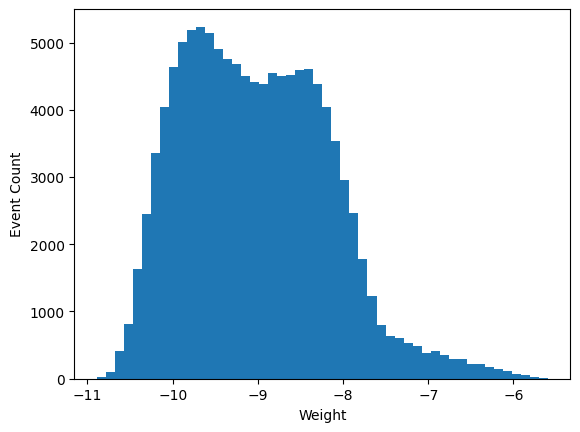

In [12]:
plt.figure()
plt.hist(np.log10(gibuu_df["net_weight"].to_numpy()),bins=50)
plt.xlabel("Weight")
plt.ylabel("Event Count")
plt.show()

In [13]:
f_lowE_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_lowE_overlay_run4b_rhc_train.root")["wcpselection"]
f_lowE_overlay_bdt = f_lowE_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_lowE_overlay_eval = f_lowE_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_lowE_overlay_pfeval = f_lowE_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_lowE_overlay_kine = f_lowE_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_lowE_overlay_pot = f_lowE_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
lowE_overlay_POT = np.sum(f_lowE_overlay_pot["pot_tor875good"].to_numpy())
lowE_overlay_df = pd.concat([f_lowE_overlay_bdt, f_lowE_overlay_eval, f_lowE_overlay_pfeval, f_lowE_overlay_kine], axis=1, sort=False)

lowE_overlay_df["horncur"] = ["RHC" for i in range(lowE_overlay_df.shape[0])]

del f_lowE_overlay
del f_lowE_overlay_bdt
del f_lowE_overlay_eval
del f_lowE_overlay_pfeval
del f_lowE_overlay_kine

if not single_run: 
    f_lowE_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_lowE_overlay_run1_fhc_train.root")["wcpselection"]
    f_lowE_overlay_bdt = f_lowE_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_lowE_overlay_eval = f_lowE_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_lowE_overlay_pfeval = f_lowE_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_lowE_overlay_kine = f_lowE_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_lowE_overlay_pot = f_lowE_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
    lowE_overlay_POT = np.sum(f_lowE_overlay_pot["pot_tor875good"].to_numpy())
    lowE_overlay_df_2 = pd.concat([f_lowE_overlay_bdt, f_lowE_overlay_eval, f_lowE_overlay_pfeval, f_lowE_overlay_kine], axis=1, sort=False)

    lowE_overlay_df_2["horncur"] = ["FHC" for i in range(lowE_overlay_df_2.shape[0])]
    
    del f_lowE_overlay
    del f_lowE_overlay_bdt
    del f_lowE_overlay_eval
    del f_lowE_overlay_pfeval
    del f_lowE_overlay_kine

    lowE_overlay_df = pd.concat([lowE_overlay_df, lowE_overlay_df_2], sort=False)

lowE_overlay_df = kdar.apply_goodruns(lowE_overlay_df)

lowE_overlay_df["net_weight"] = lowE_overlay_df["weight_cv"].to_numpy()*lowE_overlay_df["weight_spline"].to_numpy()
print("All events",lowE_overlay_df.shape[0],np.sum(lowE_overlay_df["net_weight"].to_numpy()))

lowE_overlay_df["rse_num"] = (lowE_overlay_df["run"].to_numpy() * 100_000_000_000
                         + lowE_overlay_df["subrun"].to_numpy() * 1_000_000
                         + lowE_overlay_df["event"].to_numpy())
lowE_overlay_df = lowE_overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",lowE_overlay_df.shape[0],np.sum(lowE_overlay_df["net_weight"].to_numpy()))

lowE_overlay_df["isEXT"] = [0 for i in range(lowE_overlay_df.shape[0])]
lowE_overlay_df["isDirt"] = [0 for i in range(lowE_overlay_df.shape[0])]
lowE_overlay_df["WC_file"] = ["numi_lowE_overlay" for i in range(lowE_overlay_df.shape[0])]
lowE_overlay_df["POTscaled"] = [1 for i in range(lowE_overlay_df.shape[0])]




All events 169786 191417.02
Duplicates Dropped 169786 191417.02


In [14]:
f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_oldflux_overlay_run4b_rhc_train.root")["wcpselection"]
f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_overlay_pot = f_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
overlay_POT = np.sum(f_overlay_pot["pot_tor875good"].to_numpy())
overlay_df = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine], axis=1, sort=False)

overlay_df["horncur"] = ["RHC" for i in range(overlay_df.shape[0])]

del f_overlay
del f_overlay_bdt
del f_overlay_eval
del f_overlay_pfeval
del f_overlay_kine

if not single_run: 
    f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_oldflux_overlay_run1_fhc_train.root")["wcpselection"]
    f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_overlay_pot = f_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
    overlay_POT = np.sum(f_overlay_pot["pot_tor875good"].to_numpy())
    overlay_df_2 = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine], axis=1, sort=False)

    overlay_df_2["horncur"] = ["FHC" for i in range(overlay_df_2.shape[0])]
    
    del f_overlay
    del f_overlay_bdt
    del f_overlay_eval
    del f_overlay_pfeval
    del f_overlay_kine

    overlay_df = pd.concat([overlay_df, overlay_df_2], sort=False)

overlay_df = kdar.apply_goodruns(overlay_df)

overlay_df["net_weight"] = overlay_df["weight_cv"].to_numpy()*overlay_df["weight_spline"].to_numpy()
print("All events",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["rse_num"] = (overlay_df["run"].to_numpy() * 100_000_000_000
                         + overlay_df["subrun"].to_numpy() * 1_000_000
                         + overlay_df["event"].to_numpy())
overlay_df = overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["isEXT"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["isDirt"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["WC_file"] = ["numi_overlay" for i in range(overlay_df.shape[0])]
overlay_df["POTscaled"] = [1 for i in range(overlay_df.shape[0])]




All events 890447 676865.4
Duplicates Dropped 890447 676865.4


In [15]:

kdar_overlay_df = kdar.add_ntrue_nu_angle(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_muon_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_proton_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_ssm_info(kdar_overlay_df)

nuwro_df = kdar.add_ntrue_nu_angle(nuwro_df)
nuwro_df = kdar.add_truth_muon_info(nuwro_df)
nuwro_df = kdar.add_truth_proton_info(nuwro_df)
nuwro_df = kdar.add_truth_ssm_info(nuwro_df)

gibuu_df = kdar.add_ntrue_nu_angle(gibuu_df)
gibuu_df = kdar.add_truth_muon_info(gibuu_df)
gibuu_df = kdar.add_truth_proton_info(gibuu_df)
gibuu_df = kdar.add_truth_ssm_info(gibuu_df)


lowE_overlay_df = kdar.add_ntrue_nu_angle(lowE_overlay_df)
lowE_overlay_df = kdar.add_truth_muon_info(lowE_overlay_df)
lowE_overlay_df = kdar.add_truth_proton_info(lowE_overlay_df)
lowE_overlay_df = kdar.add_truth_ssm_info(lowE_overlay_df)

overlay_df = kdar.add_ntrue_nu_angle(overlay_df)
overlay_df = kdar.add_truth_muon_info(overlay_df)
overlay_df = kdar.add_truth_proton_info(overlay_df)
overlay_df = kdar.add_truth_ssm_info(overlay_df)


 54%|█████████████████▊               | 61703/114674 [00:01<00:00, 60188.99it/s]/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2232: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos(cos)
  0%|                                                | 0/169786 [00:00<?, ?it/s]/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2243: RuntimeWarning: invalid value encountered in sqrt
  true_W.append( np.sqrt(938*938 + 2*938*true_nu[-1] - true_Q2[-1]) )
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2237: RuntimeWarning: invalid value encountered in sqrt
  true_sqrtQ2.append( np.sqrt(2*235.5*(Emu[event]-k[event]*cos)-105.7*105.7 ))
  0%|                                                | 0/890447 [00:00<?, ?it/s]/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2243: RuntimeWarning: invalid value encountered in sqrt
  true_W.append( np.sqrt(938*938 + 2*938*true_nu[-1] - true_Q2[-1]) )
/Users/bbogart/Documents/analy

In [16]:

print("Total",lowE_overlay_df.shape[0],np.sum(lowE_overlay_df["net_weight"].to_numpy()))
lowE_overlay_df = kdar.set_is_kdar(lowE_overlay_df)
lowE_overlay_df = lowE_overlay_df.query("is_KDAR==0")
print("No KDARs",lowE_overlay_df.shape[0],np.sum(lowE_overlay_df["net_weight"].to_numpy()))


Total 169786 191417.02
No KDARs 166018 186294.47


In [17]:

print("Total",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))
overlay_df = kdar.set_is_kdar(overlay_df)
overlay_df = overlay_df.query("is_KDAR==0")
print("No KDARs",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))
overlay_df = overlay_df.query("is_KDAR==0")
print("No KDARs",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))
overlay_df = overlay_df.query("not(truth_nuEnergy<400 and truth_isCC==1 and abs(truth_nuPdg)==14)")
print("No lowE",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))


Total 890447 676865.4
No KDARs 890013 675944.5
No KDARs 890013 675944.5
No lowE 852480 640433.44


In [18]:

kdar_overlay_df = kdar.add_ssm_kine_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_ssm_reco_proton_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_reco_proton_muon(kdar_overlay_df)
kdar_overlay_df = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df)

nuwro_df = kdar.add_ssm_kine_info(nuwro_df)
nuwro_df = kdar.add_ssm_reco_proton_info(nuwro_df)
nuwro_df = kdar.add_reco_proton_muon(nuwro_df)
nuwro_df = kdar.add_ssm_reco_dirt_vars(nuwro_df)

gibuu_df = kdar.add_ssm_kine_info(gibuu_df)
gibuu_df = kdar.add_ssm_reco_proton_info(gibuu_df)
gibuu_df = kdar.add_reco_proton_muon(gibuu_df)
gibuu_df = kdar.add_ssm_reco_dirt_vars(gibuu_df)

lowE_overlay_df = kdar.add_ssm_kine_info(lowE_overlay_df)
lowE_overlay_df = kdar.add_ssm_reco_proton_info(lowE_overlay_df)
lowE_overlay_df = kdar.add_reco_proton_muon(lowE_overlay_df)
lowE_overlay_df = kdar.add_ssm_reco_dirt_vars(lowE_overlay_df)

overlay_df = kdar.add_ssm_kine_info(overlay_df)
overlay_df = kdar.add_ssm_reco_proton_info(overlay_df)
overlay_df = kdar.add_reco_proton_muon(overlay_df)
overlay_df = kdar.add_ssm_reco_dirt_vars(overlay_df)



100%|█████████████████████████████████| 84722/84722 [00:00<00:00, 598091.06it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2446: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ssm_cosMuP"] = cosMuP
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2447: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ssm_angle_MuP"] = angle_MuP
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2448: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling

In [19]:

temp_kdar_df = kdar_overlay_df.query(kdar.presel_query).reset_index()
temp_nuwro_df = nuwro_df.query(kdar.presel_query).reset_index()
temp_gibuu_df = gibuu_df.query(kdar.presel_query).reset_index()
temp_lowE_df = lowE_overlay_df.query(kdar.presel_query).reset_index()
temp_overlay_df = overlay_df.query(kdar.presel_query).reset_index()

train_kdar_df = temp_kdar_df.query("event%10<4")
train_nuwro_df = temp_nuwro_df.query("event%10<5")
train_gibuu_df = temp_gibuu_df.query("event%10<5")
train_lowE_df = temp_lowE_df.query("event%10<7")
train_overlay_df = temp_overlay_df.query("event%10<7")

test_kdar_df = temp_kdar_df.drop(train_kdar_df.index)
test_nuwro_df = temp_nuwro_df.drop(train_nuwro_df.index)
test_gibuu_df = temp_gibuu_df.drop(train_gibuu_df.index)
test_lowE_df = temp_lowE_df.drop(train_lowE_df.index)
test_overlay_df = temp_overlay_df.drop(train_overlay_df.index)

print("GiBUU",train_gibuu_df.shape[0])
train_gibuu_df = train_gibuu_df.sample(n=3000,weights=train_gibuu_df["net_weight"].to_numpy(),random_state=777).reset_index()
print("Downsample GiBUU",train_gibuu_df.shape[0])

GiBUU 22300
Downsample GiBUU 3000


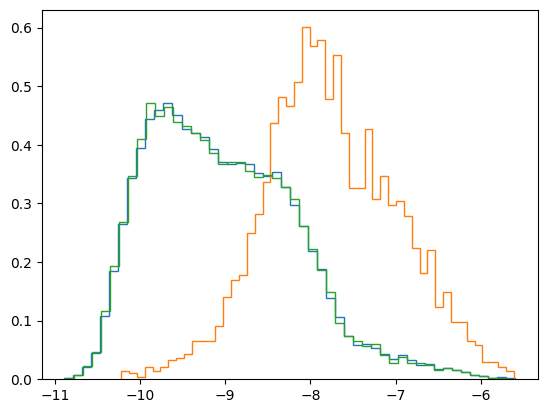

In [20]:
plt.figure()
plt.hist(np.log10(gibuu_df.query(kdar.presel_query)["net_weight"].to_numpy()),bins=50,histtype='step',density=True)
plt.hist(np.log10(train_gibuu_df["net_weight"].to_numpy()),bins=50,histtype='step',density=True)
plt.hist(np.log10(test_gibuu_df["net_weight"].to_numpy()),bins=50,histtype='step',density=True)
plt.show()

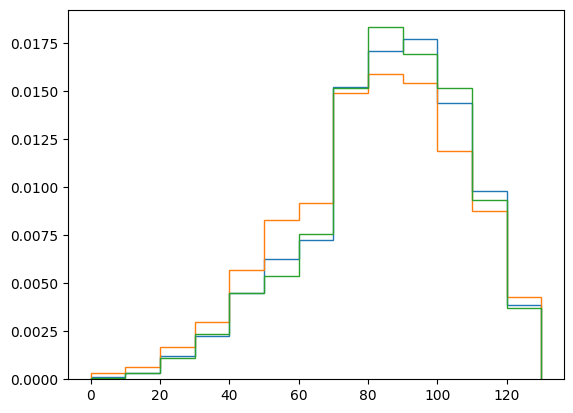

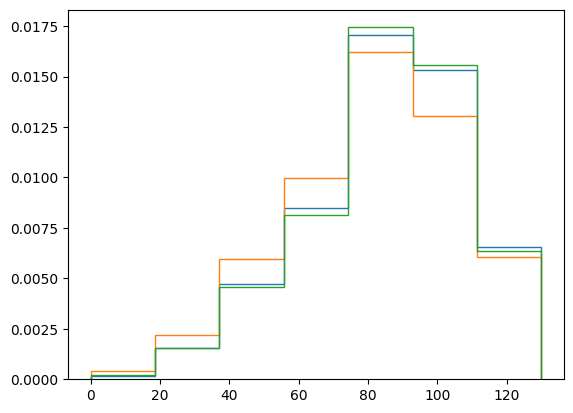

In [21]:
plt.figure()
plt.hist(gibuu_df.query(kdar.presel_query)["truth_Emuon"].to_numpy(),weights=gibuu_df.query(kdar.presel_query)["net_weight"].to_numpy(),bins=13,range=(0,130),histtype='step',density=True)
plt.hist(train_gibuu_df["truth_Emuon"].to_numpy(),bins=13,range=(0,130),histtype='step',density=True)
plt.hist(test_gibuu_df["truth_Emuon"].to_numpy(),weights=test_gibuu_df["net_weight"].to_numpy(),bins=13,range=(0,130),histtype='step',density=True)
plt.show()

plt.figure()
plt.hist(gibuu_df.query(kdar.presel_query)["truth_Emuon"].to_numpy(),weights=gibuu_df.query(kdar.presel_query)["net_weight"].to_numpy(),bins=7,range=(0,130),histtype='step',density=True)
plt.hist(train_gibuu_df["truth_Emuon"].to_numpy(),bins=7,range=(0,130),histtype='step',density=True)
plt.hist(test_gibuu_df["truth_Emuon"].to_numpy(),weights=test_gibuu_df["net_weight"].to_numpy(),bins=7,range=(0,130),histtype='step',density=True)
plt.show()

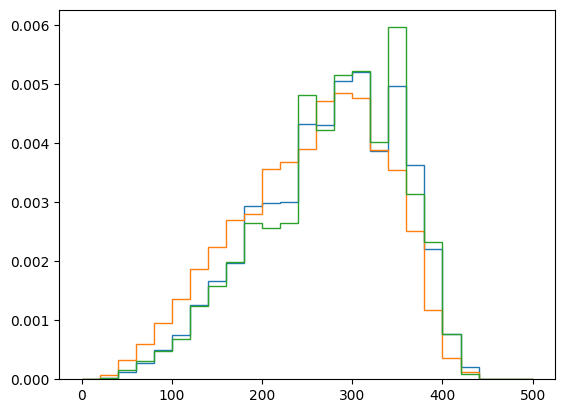

In [22]:
plt.figure()
plt.hist(gibuu_df.query(kdar.presel_query)["true_q"].to_numpy(),weights=gibuu_df.query(kdar.presel_query)["net_weight"].to_numpy(),bins=25,range=(0,500),histtype='step',density=True)
plt.hist(train_gibuu_df["true_q"].to_numpy(),bins=25,range=(0,500),histtype='step',density=True)
plt.hist(test_gibuu_df["true_q"].to_numpy(),weights=test_gibuu_df["net_weight"].to_numpy(),bins=25,range=(0,500),histtype='step',density=True)
plt.show()

In [23]:
print("GENIE",train_kdar_df.shape[0])
print("NuWro",train_nuwro_df.shape[0])
print("GiBUU",train_gibuu_df.shape[0])
print("lowE",train_lowE_df.shape[0])
print("hiE",train_overlay_df.shape[0])

GENIE 12326
NuWro 5727
GiBUU 3000
lowE 10194
hiE 5444


In [24]:

check_df = pd.concat([train_kdar_df, test_kdar_df], sort=False)
overlap_check_df = check_df.drop_duplicates(subset=['rse_num'],keep=False)
print("Overlap for KDAR GENIE: ", check_df.shape[0] - overlap_check_df.shape[0])
del check_df
del overlap_check_df

check_df = pd.concat([train_nuwro_df, test_nuwro_df], sort=False)
overlap_check_df = check_df.drop_duplicates(subset=['rse_num'],keep=False)
print("Overlap for KDAR NuWro: ", check_df.shape[0] - overlap_check_df.shape[0])
del check_df
del overlap_check_df

check_df = pd.concat([train_gibuu_df, test_gibuu_df], sort=False)
overlap_check_df = check_df.drop_duplicates(subset=['rse_num'],keep=False)
print("Overlap for KDAR GiBUU: ", check_df.shape[0] - overlap_check_df.shape[0])
del check_df
del overlap_check_df

check_df = pd.concat([train_lowE_df, test_lowE_df], sort=False)
overlap_check_df = check_df.drop_duplicates(subset=['rse_num'],keep=False)
print("Overlap for lowE: ", check_df.shape[0] - overlap_check_df.shape[0])
del check_df
del overlap_check_df

check_df = pd.concat([train_overlay_df, test_overlay_df], sort=False)
overlap_check_df = check_df.drop_duplicates(subset=['rse_num'],keep=False)
print("Overlap for hiE: ", check_df.shape[0] - overlap_check_df.shape[0])
del check_df
del overlap_check_df

Overlap for KDAR GENIE:  0
Overlap for KDAR NuWro:  0
Overlap for KDAR GiBUU:  0
Overlap for lowE:  0
Overlap for hiE:  0


In [25]:

train_vars = []
train_vars = kdar.train_vars_nokineprim


fraction = 0.6
num_vars = 500
n = 100
num_classes=2

train_df  = pd.concat([train_kdar_df, train_lowE_df], sort=False)
test_df  = pd.concat([test_kdar_df, test_lowE_df], sort=False)

# Extract feature and target arrays
X_test, y_test = test_df.fillna(0)[train_vars].copy(), test_df[['is_KDAR']].copy()
X_train, y_train = train_df.fillna(0)[train_vars].copy(), train_df[['is_KDAR']].copy()
    
presel_model_lowE_genie_only = SelectKBest(f_classif, k=num_vars).fit(X_train, y_train)
new_names_lowE_genie_only = list(presel_model_lowE_genie_only.get_feature_names_out())

X_train = presel_model_lowE_genie_only.transform(X_train)
X_test = presel_model_lowE_genie_only.transform(X_test)

# Define the hyperparameter distributions
param_dist = {
    'max_depth': stats.randint(3, 10),
    'eta': stats.uniform(0, 1),
    'gamma':stats.uniform(2, 30),
    'lambda':stats.uniform(0, 10),
    'alpha':stats.uniform(0, 10),
    'min_child_weight':stats.uniform(0, 10),
     'colsample_bytree': stats.uniform(0.5, 0.5),
     'colsample_bylevel': stats.uniform(0.5, 0.5)
}

# Create the XGBoost model object
xgb_model_lowE_genie_only = xgb.XGBClassifier(random_state=777)

# Create the RandomizedSearchCV object
random_search_lowE_genie_only = RandomizedSearchCV(xgb_model_lowE_genie_only, param_distributions=param_dist, n_iter=100, cv=5, scoring='roc_auc',random_state=777)

# Fit the RandomizedSearchCV object to the training data
random_search_lowE_genie_only.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", random_search_lowE_genie_only.best_params_)
print("Best score: ", random_search_lowE_genie_only.best_score_)

new_params_lowE_genie_only = random_search_lowE_genie_only.best_params_
new_params_lowE_genie_only["objective"] =  "binary:logistic"
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True,feature_names=new_names_lowE_genie_only)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True,feature_names=new_names_lowE_genie_only)
evals = [(dtest_reg, "validation"), (dtrain_reg, "train")]
evals_result_lowE_genie_only = {}
model_lowE_genie_only = xgb.train(
   params=random_search_lowE_genie_only.best_params_,
   dtrain=dtrain_reg,
   num_boost_round=n,
   evals=evals,
   verbose_eval=200,
    evals_result=evals_result_lowE_genie_only
)



/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=500 is greater than n_features=319. All the features will be returned.
  warnings.warn(
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [313 314 316 317] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best set of hyperparameters:  {'alpha': 2.4713217317766336, 'colsample_bylevel': 0.5346937169270016, 'colsample_bytree': 0.6164574387308318, 'eta': 0.0941897694250926, 'gamma': 3.3077013483976643, 'lambda': 6.939471118550566, 'max_depth': 5, 'min_child_weight': 9.009693564158018}
Best score:  0.7999204181236574
[0]	validation-logloss:0.62536	train-logloss:0.67413
[99]	validation-logloss:0.47666	train-logloss:0.48291


In [26]:

assign_bdt_vars(model_lowE_genie_only,new_names_lowE_genie_only,"kdar_score_lowE_genie_only")



[0.77517474 0.80506027 0.8206474  ... 0.3627874  0.08849326 0.3627874 ]


/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  kdar_overlay_df[bdt_var] = d_pred
/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_kdar_df[bdt_var] = d_pred
/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

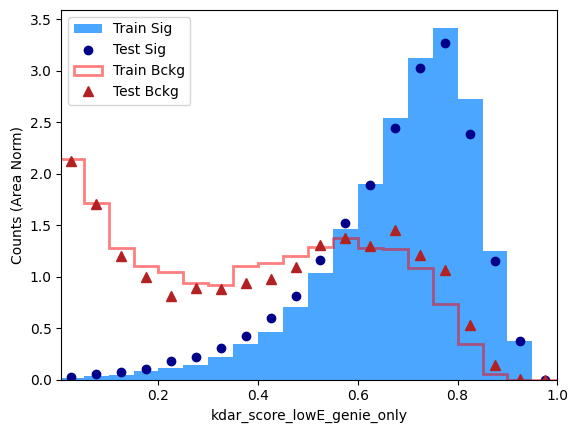

[2.33124042 1.70329687 1.16954486 0.9733125  0.75353226 0.94976462
 0.80062802 0.9654632  1.06750403 1.13814768 1.2558871  1.40502369
 1.3893251  1.35792792 1.05180544 1.03610685 0.50235484 0.1412873
 0.00784929 0.        ]


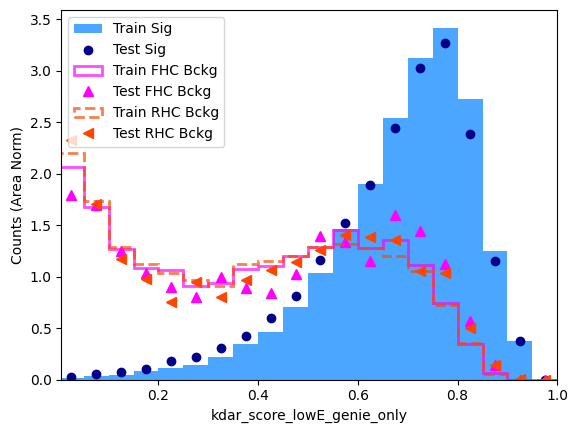

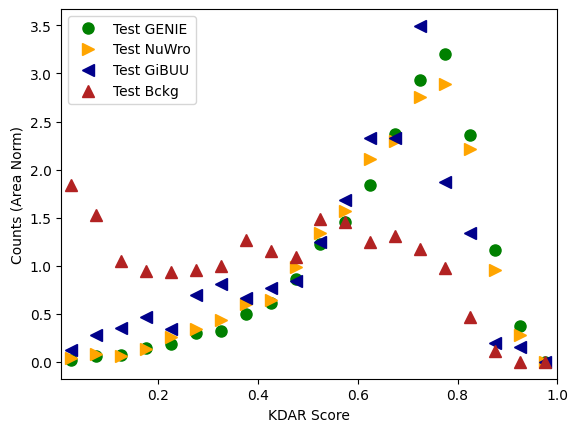

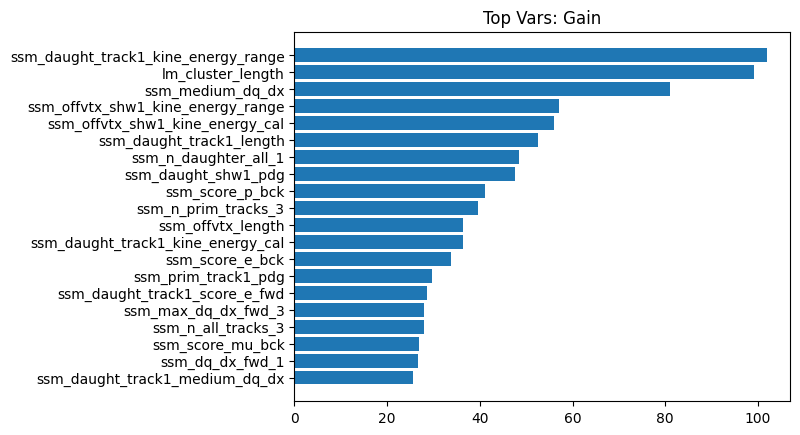

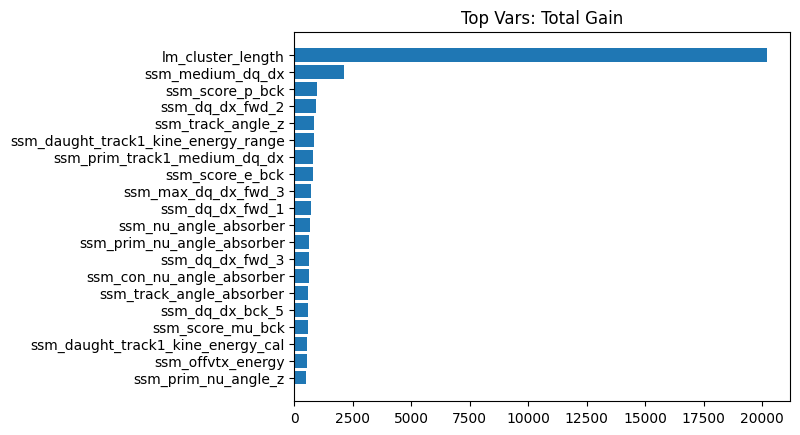

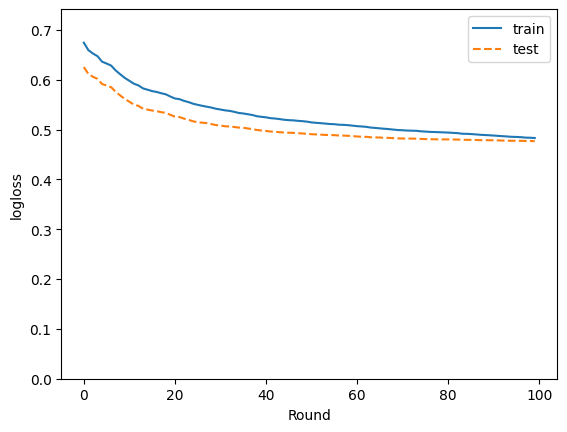

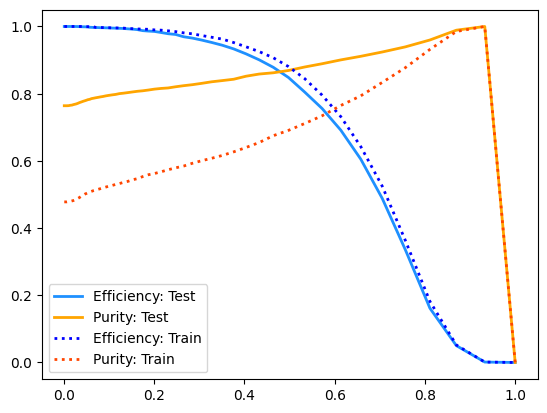

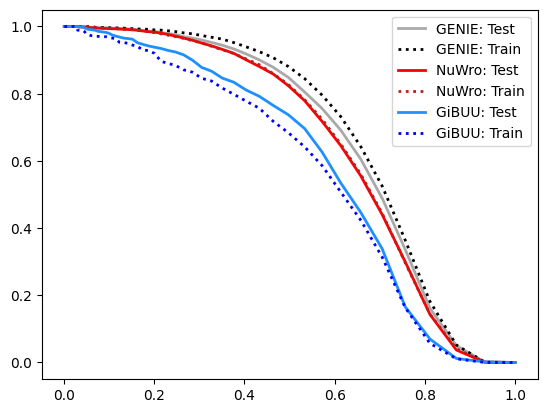

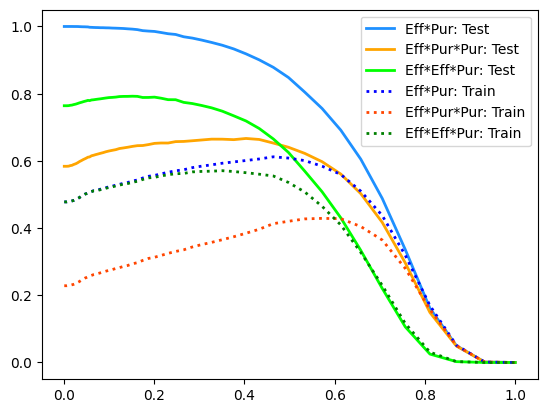

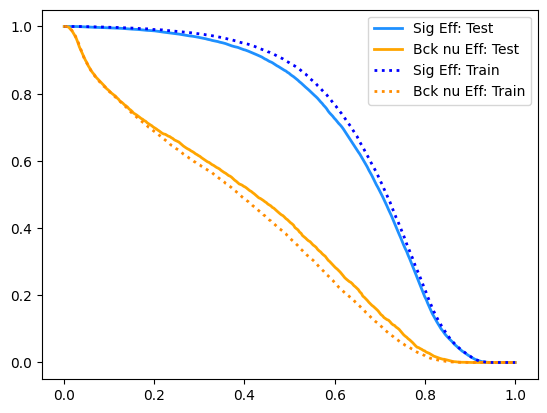

In [27]:

evaluate_BDT(model_lowE_genie_only,"kdar_score_lowE_genie_only",evals_result_lowE_genie_only,max_items=20)


In [28]:

this_cutvalue = 0.75
this_bdt_var = "kdar_score_lowE_genie_only"

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Train BDT lowE passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT lowE passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("Train BDT hiE passrate:",round(np.sum(train_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))
print("Test BDT hiE passrate:",round(np.sum(test_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))



old gen sel lowE passrate: 0.235
gen sel lowE passrate: 0.263
pre sel lowE passrate: 0.094
Train BDT lowE passrate: 0.005
Test BDT lowE passrate: 0.007

old gen sel hiE passrate: 0.308
gen sel hiE passrate: 0.316
pre sel hiE passrate: 0.01
Train BDT hiE passrate: 0.0002
Test BDT hiE passrate: 0.0002


In [29]:

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE rel passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT lowE rel passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy()),3))
print("Test BDT lowE rel passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE rel passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT hiE rel passrate:",round(np.sum(train_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT hiE rel passrate:",round(np.sum(test_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy()),3))



old gen sel lowE passrate: 0.235
gen sel lowE passrate: 0.263
pre sel lowE rel passrate: 0.356
Train BDT lowE rel passrate: 0.052
Test BDT lowE rel passrate: 0.078

old gen sel hiE passrate: 0.308
gen sel hiE passrate: 0.316
pre sel hiE rel passrate: 0.031
Train BDT hiE rel passrate: 0.016
Test BDT hiE rel passrate: 0.023


0.28465154469013215


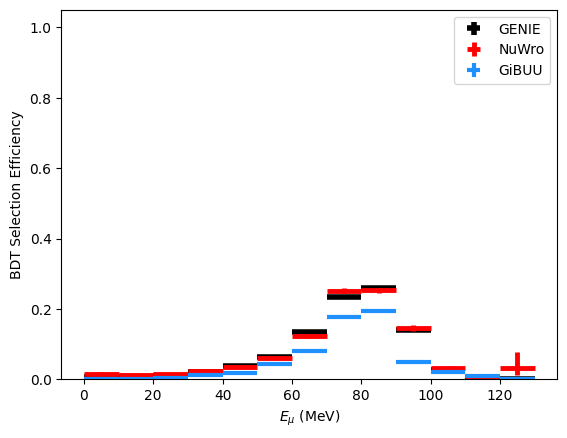

0.16811466068029404


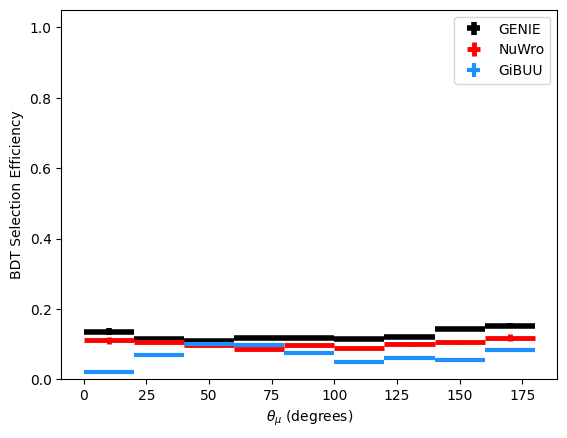

0.2166505558240696


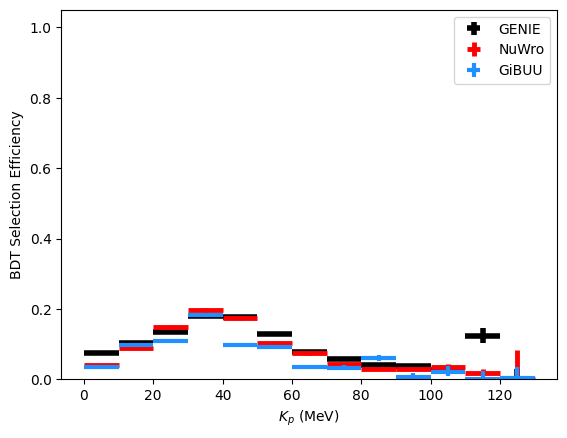

0.1495396062731743


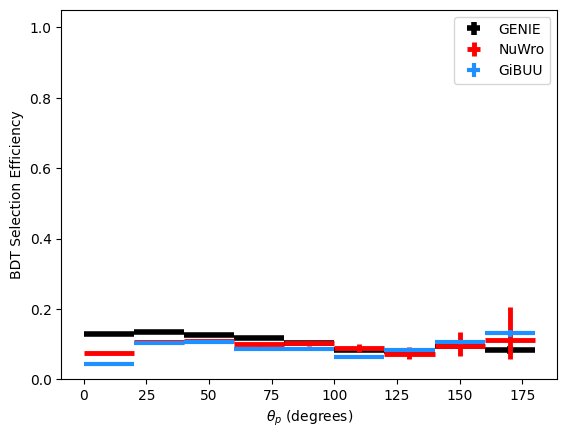

0.18653929233551028


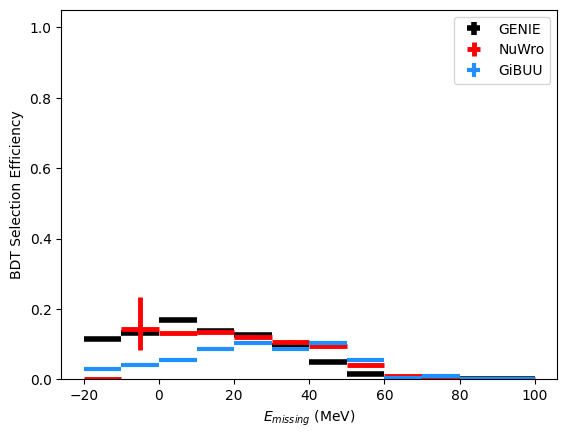

0.29568677544593813


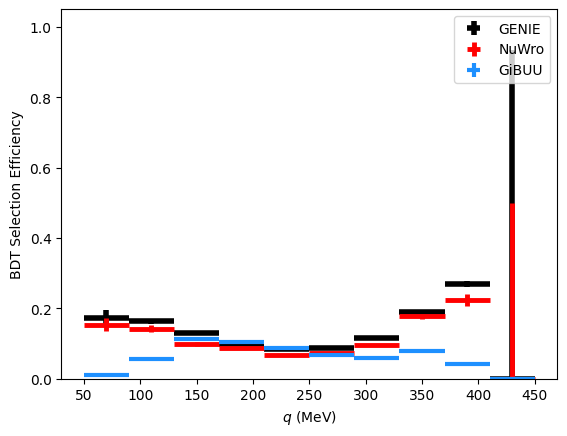

0.2863452881574631


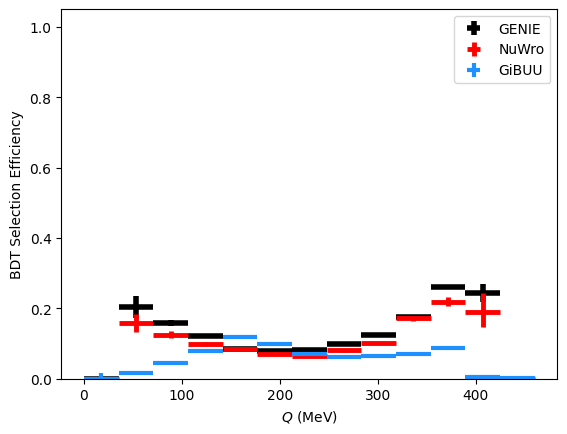

0.28689508438110356


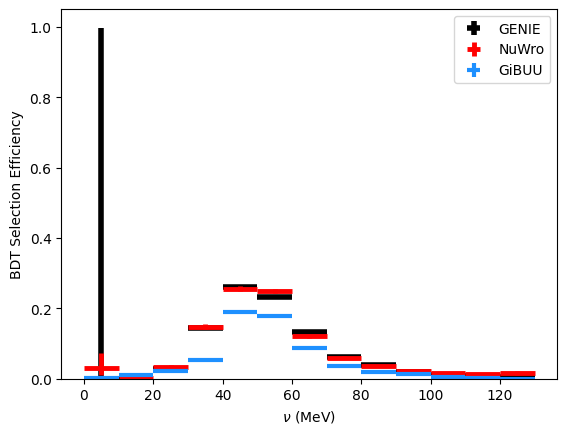

0.3218085106382979


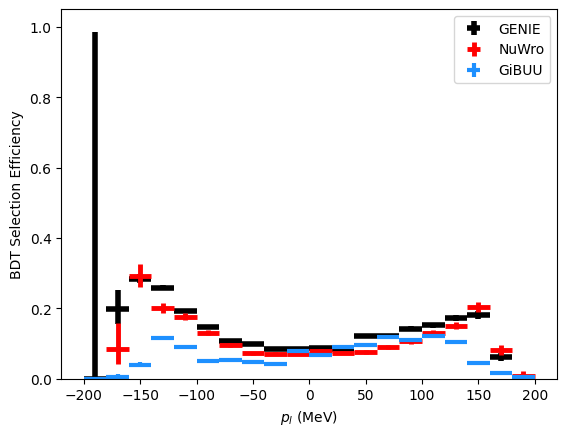

0.2538288295269013


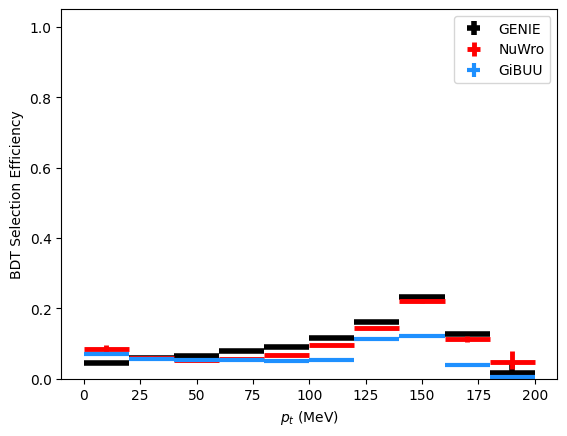

0.20049657970666887


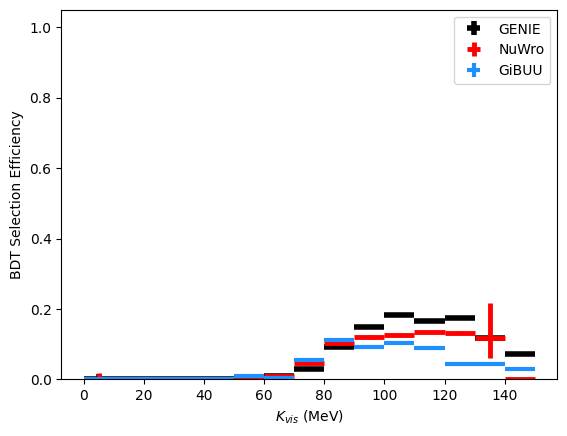

0.13226928114891054


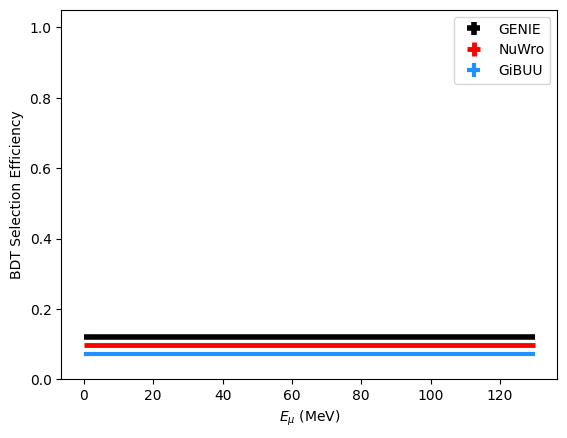

0.5540256175663312


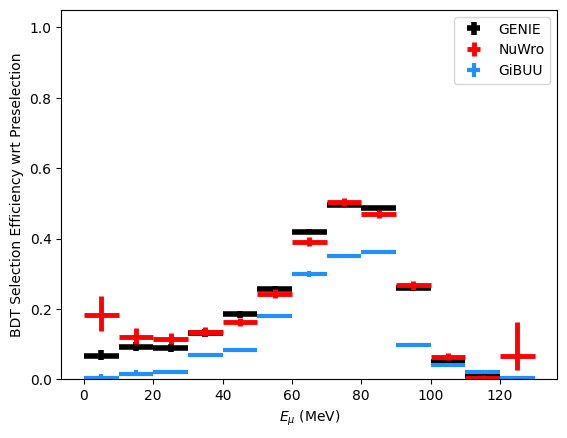

0.5363834053277969


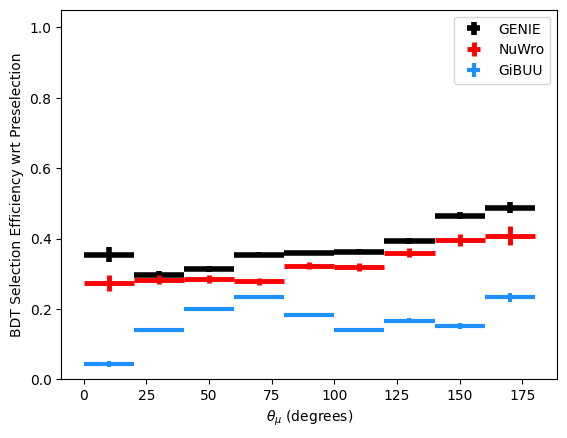

0.7321758687496186


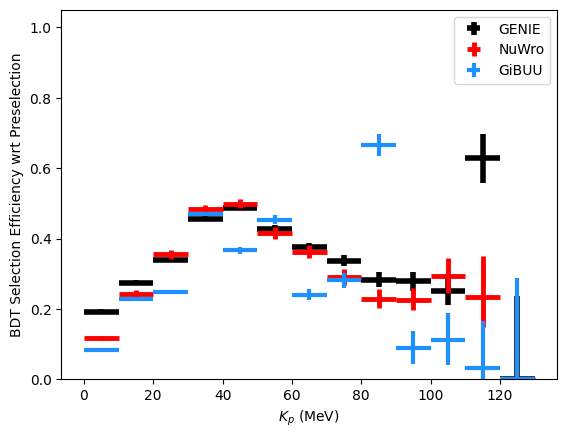

0.47790906429290775


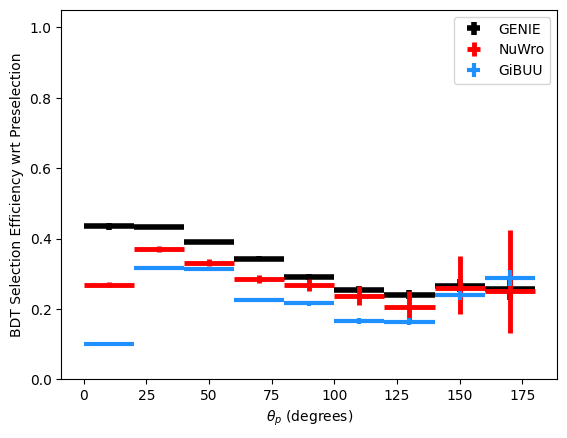

0.5162049233913422


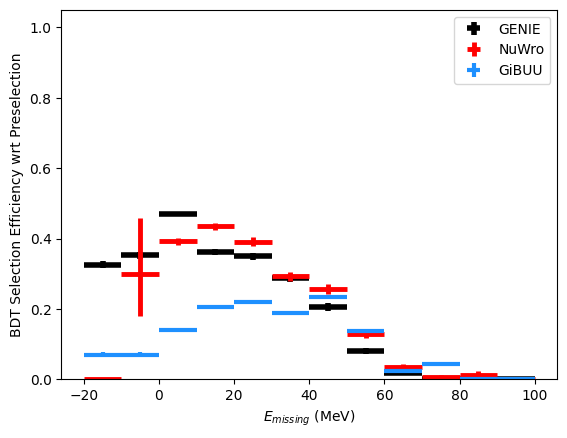

0.5309701532125474


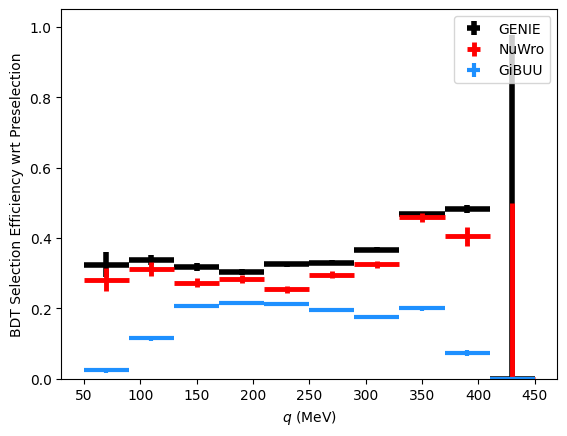

0.5527001023292542


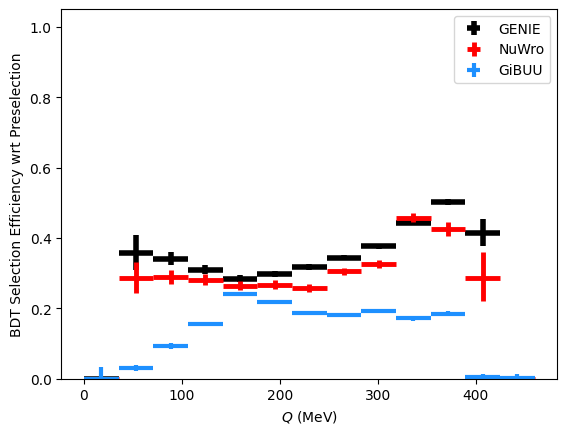

0.551766865534649


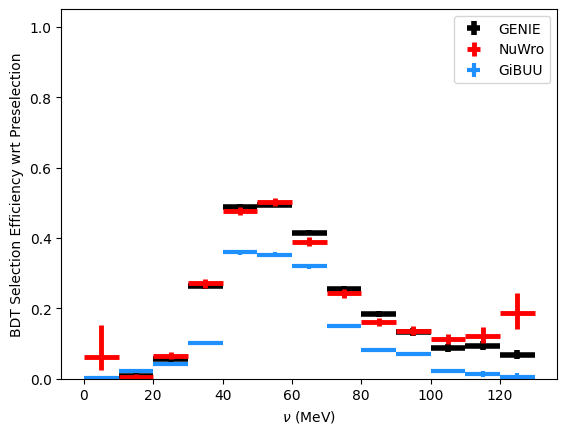

0.5941187620162964


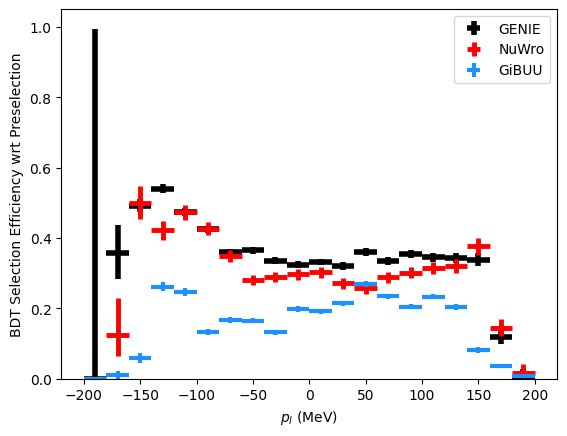

0.5003994047641754


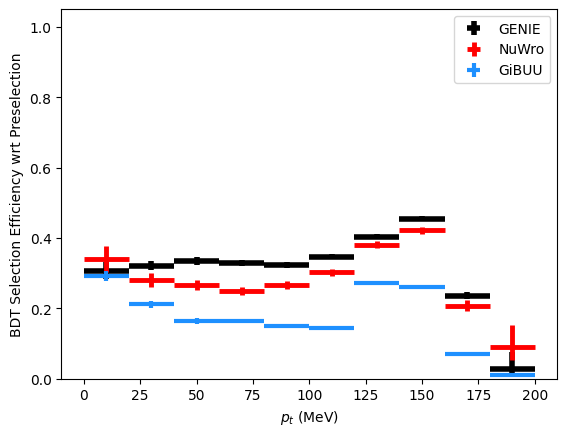

0.5257045209407807


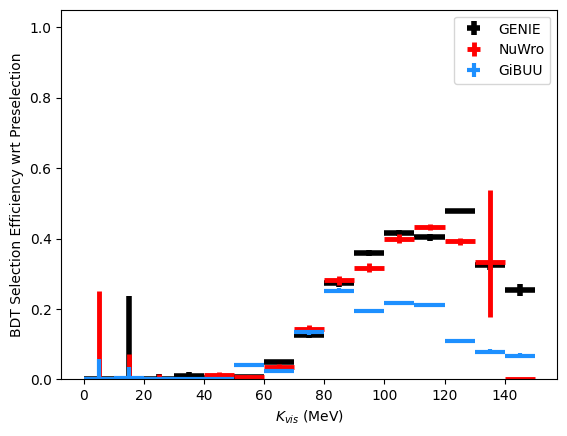

0.40605393350124364


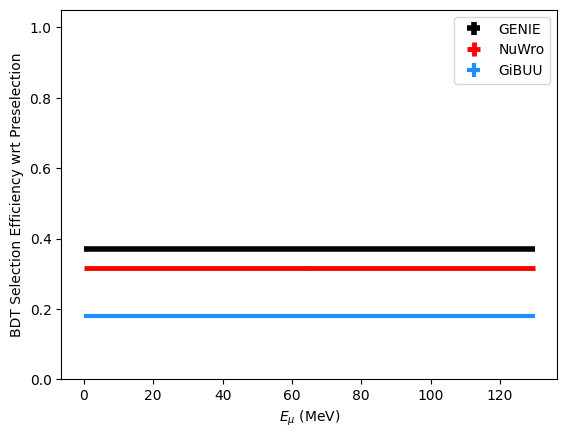

In [30]:

plot_efficiency_detailed(this_bdt_var,this_cutvalue)
plot_efficiency_detailed(this_bdt_var,this_cutvalue,wrt_preset=True)


In [31]:

if(1): 
    save_bdt(model_lowE_genie_only,"model_lowE_genie_only","_777")
    
    model_dump = model_lowE_genie_only.get_dump()
    kdar.convert_model(model_dump, input_variables=kdar.train_vars_nokineprim_tvma, output_xml= "model_lowE_genie_only_777.xml")


In [32]:

train_vars = []
train_vars = kdar.train_vars_nokineprim.copy()

fraction = 0.6
num_vars = 500
n = 200
num_classes=2

train_df  = pd.concat([train_kdar_df,train_nuwro_df,train_gibuu_df, train_lowE_df], sort=False)
test_df  = pd.concat([test_kdar_df,test_nuwro_df,test_gibuu_df, test_lowE_df], sort=False)

# Extract feature and target arrays
X_test, y_test = test_df.fillna(0)[train_vars].copy(), test_df[['is_KDAR']].copy()
X_train, y_train = train_df.fillna(0)[train_vars].copy(), train_df[['is_KDAR']].copy()
    
presel_model_lowE = SelectKBest(f_classif, k=num_vars).fit(X_train, y_train)
new_names_lowE = list(presel_model_lowE.get_feature_names_out())

X_train = presel_model_lowE.transform(X_train)
X_test = presel_model_lowE.transform(X_test)

# Define the hyperparameter distributions
param_dist = {
    'max_depth': stats.randint(3, 10),
    'eta': stats.uniform(0, 1),
    'gamma':stats.uniform(2, 30),
    'lambda':stats.uniform(0, 10),
    'alpha':stats.uniform(0, 10),
    'min_child_weight':stats.uniform(0, 10),
     'colsample_bytree': stats.uniform(0.5, 0.5),
     'colsample_bylevel': stats.uniform(0.5, 0.5)
}

# Create the XGBoost model object
xgb_model_lowE = xgb.XGBClassifier(random_state=777)

# Create the RandomizedSearchCV object
random_search_lowE = RandomizedSearchCV(xgb_model_lowE, param_distributions=param_dist, n_iter=100, cv=5, scoring='roc_auc',random_state=777)

# Fit the RandomizedSearchCV object to the training data
random_search_lowE.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", random_search_lowE.best_params_)
print("Best score: ", random_search_lowE.best_score_)

new_params_lowE = random_search_lowE.best_params_
new_params_lowE["objective"] =  "binary:logistic"
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True,feature_names=new_names_lowE)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True,feature_names=new_names_lowE)
evals = [(dtest_reg, "validation"), (dtrain_reg, "train")]
evals_result_lowE = {}
model_lowE = xgb.train(
   params=random_search_lowE.best_params_,
   dtrain=dtrain_reg,
   num_boost_round=n,
   evals=evals,
   verbose_eval=200,
    evals_result=evals_result_lowE
)


/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=500 is greater than n_features=319. All the features will be returned.
  warnings.warn(
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [313 314 316 317] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best set of hyperparameters:  {'alpha': 2.4713217317766336, 'colsample_bylevel': 0.5346937169270016, 'colsample_bytree': 0.6164574387308318, 'eta': 0.0941897694250926, 'gamma': 3.3077013483976643, 'lambda': 6.939471118550566, 'max_depth': 5, 'min_child_weight': 9.009693564158018}
Best score:  0.7859253818748266
[0]	validation-logloss:0.45559	train-logloss:0.61839
[199]	validation-logloss:0.37840	train-logloss:0.44749


In [33]:

assign_bdt_vars(model_lowE,new_names_lowE,"kdar_score_lowE")


[0.855688   0.89782655 0.8963461  ... 0.48918015 0.16783084 0.48918015]


/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  kdar_overlay_df[bdt_var] = d_pred
/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_kdar_df[bdt_var] = d_pred
/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

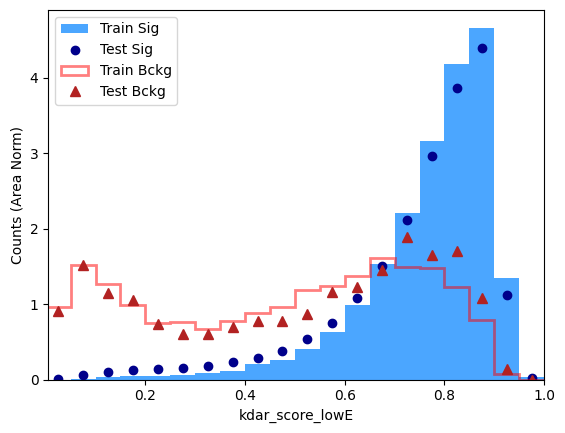

[0.94191532 1.57770816 1.18524345 1.09890121 0.68288861 0.66719002
 0.58869708 0.6907379  0.76138155 0.80847732 0.89481956 1.12244909
 1.31868145 1.48351663 1.86028276 1.59340675 1.54631099 1.03610685
 0.1412873  0.        ]


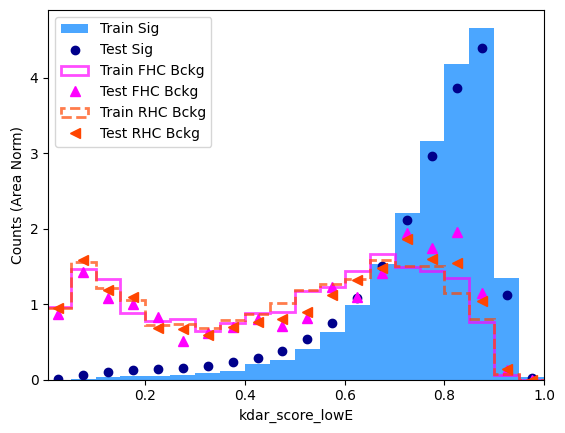

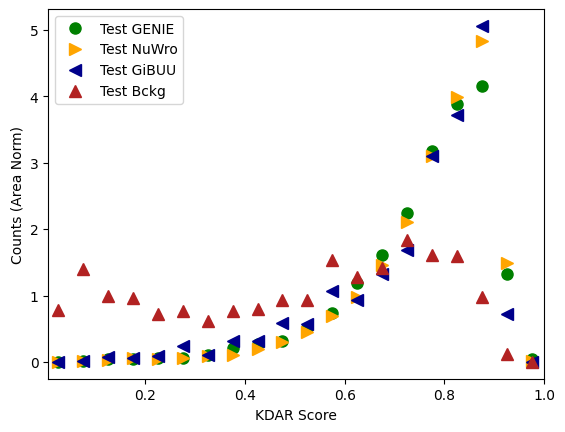

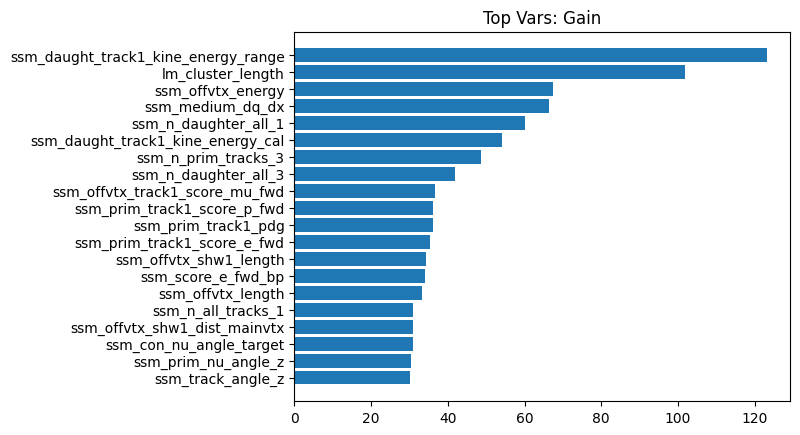

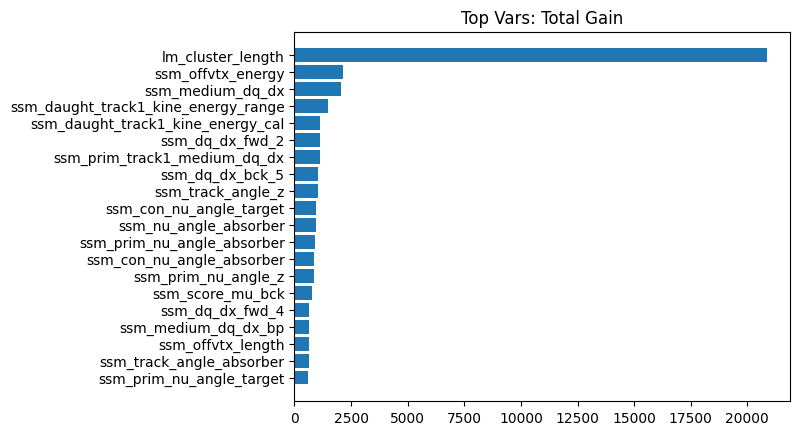

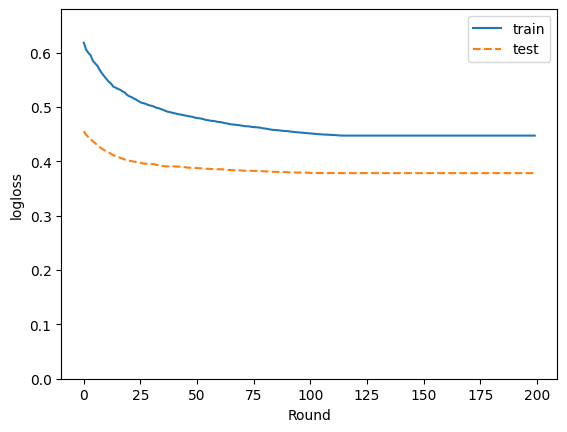

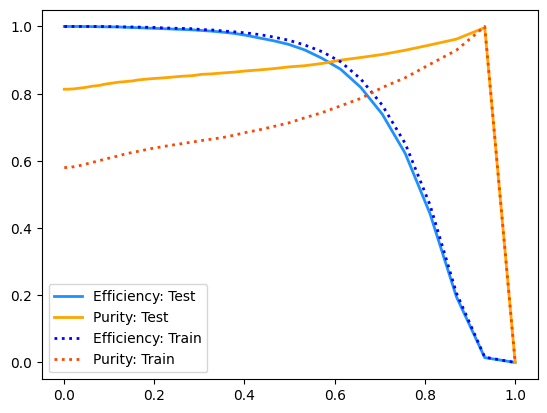

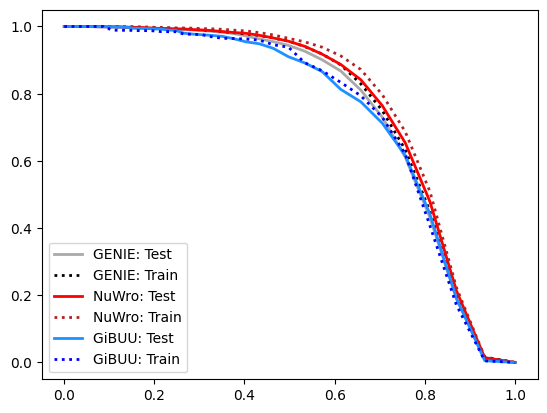

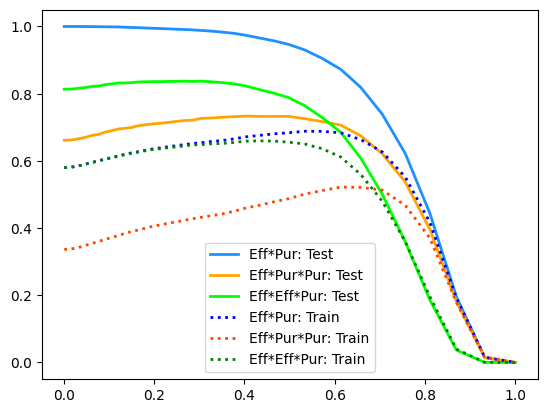

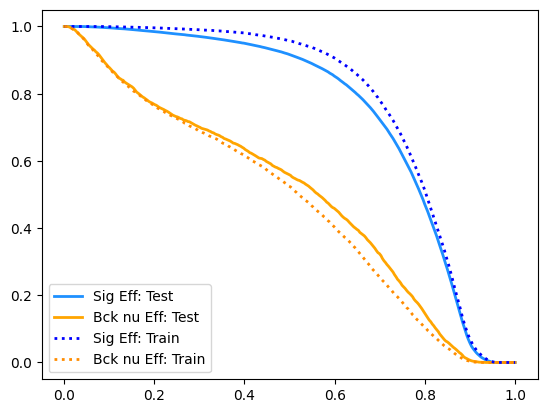

In [34]:

evaluate_BDT(model_lowE,"kdar_score_lowE",evals_result_lowE,max_items=20)


In [35]:

this_cutvalue = 0.72
this_bdt_var = "kdar_score_lowE"

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Train BDT lowE passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT lowE passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("Train BDT hiE passrate:",round(np.sum(train_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))
print("Test BDT hiE passrate:",round(np.sum(test_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))


old gen sel lowE passrate: 0.235
gen sel lowE passrate: 0.263
pre sel lowE passrate: 0.094
Train BDT lowE passrate: 0.02
Test BDT lowE passrate: 0.025

old gen sel hiE passrate: 0.308
gen sel hiE passrate: 0.316
pre sel hiE passrate: 0.01
Train BDT hiE passrate: 0.0015
Test BDT hiE passrate: 0.0015


In [36]:

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE rel passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT lowE rel passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy()),3))
print("Test BDT lowE rel passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE rel passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT hiE rel passrate:",round(np.sum(train_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT hiE rel passrate:",round(np.sum(test_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy()),3))



old gen sel lowE passrate: 0.235
gen sel lowE passrate: 0.263
pre sel lowE rel passrate: 0.356
Train BDT lowE rel passrate: 0.214
Test BDT lowE rel passrate: 0.27

old gen sel hiE passrate: 0.308
gen sel hiE passrate: 0.316
pre sel hiE rel passrate: 0.031
Train BDT hiE rel passrate: 0.152
Test BDT hiE rel passrate: 0.155


0.5108705461025238


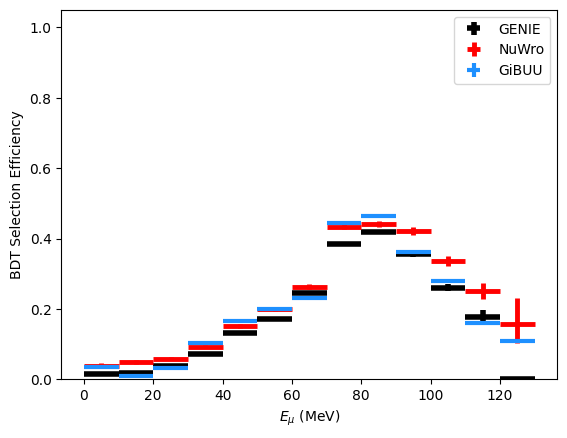

0.42156136035919195


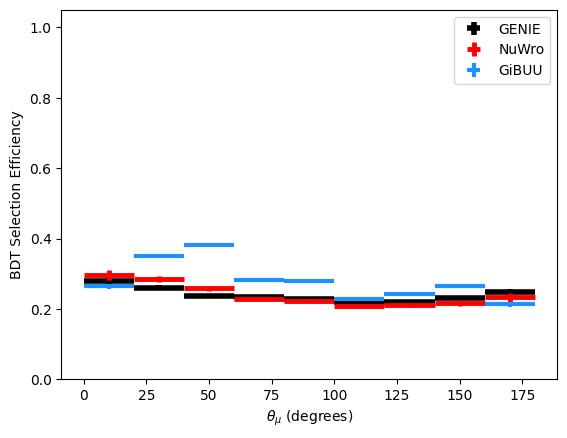

0.36317536830902103


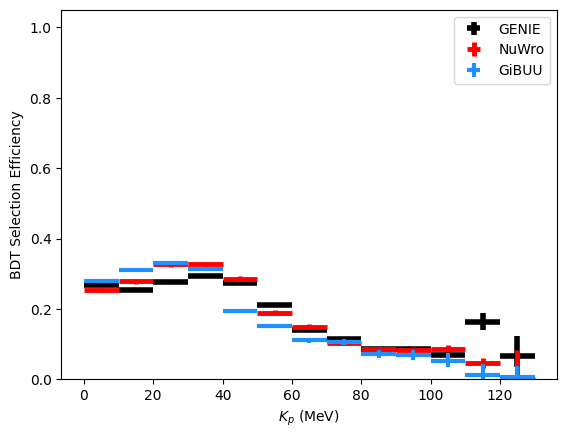

0.3810992300510407


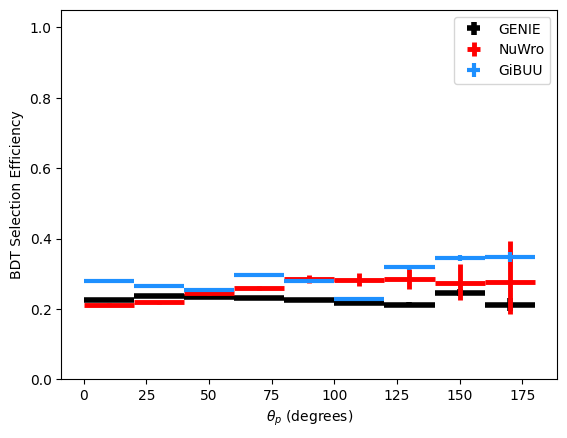

0.42998608350753786


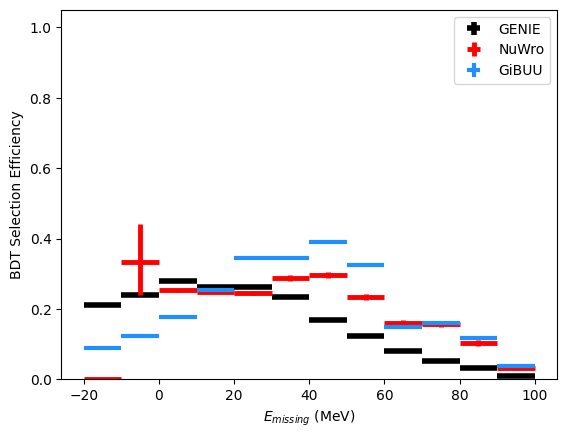

1.1


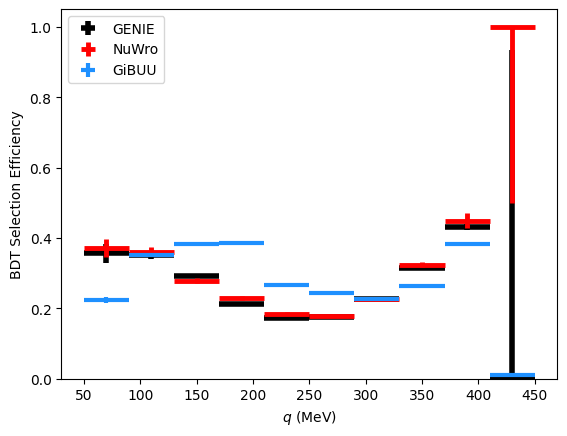

0.4714285714285714


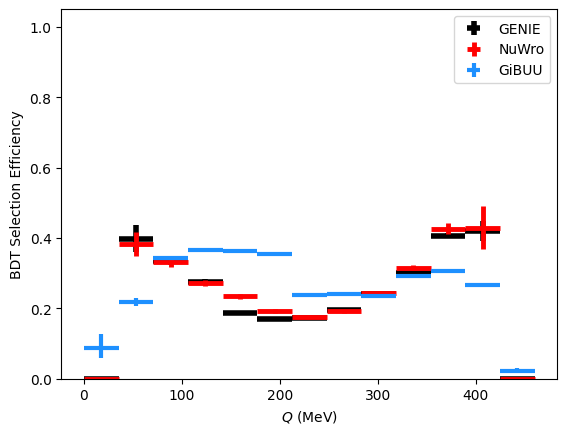

0.505592030286789


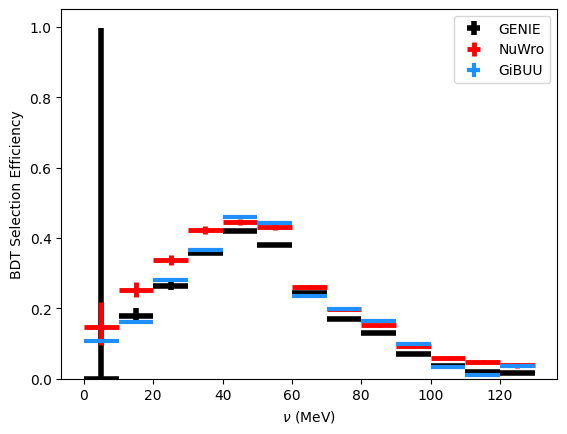

0.5544879317283631


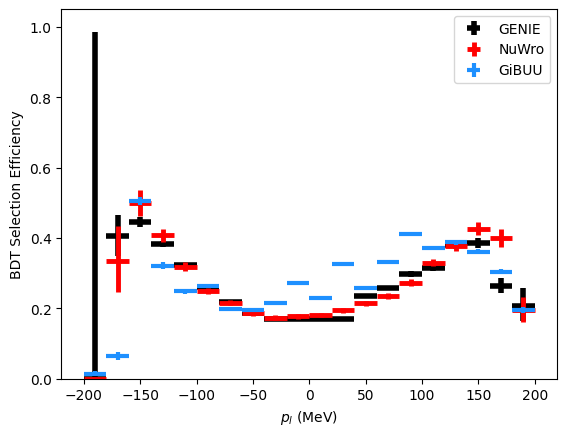

0.46874342797055735


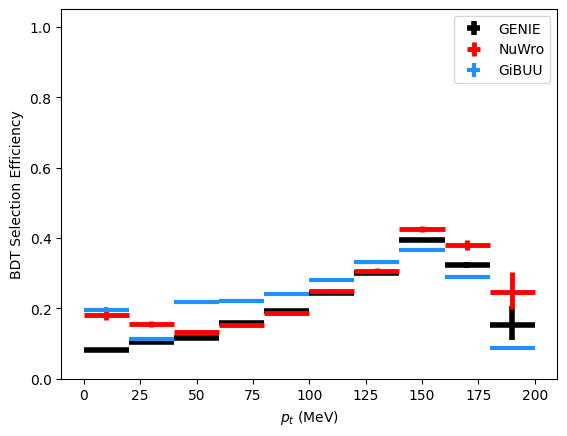

0.4310609579086304


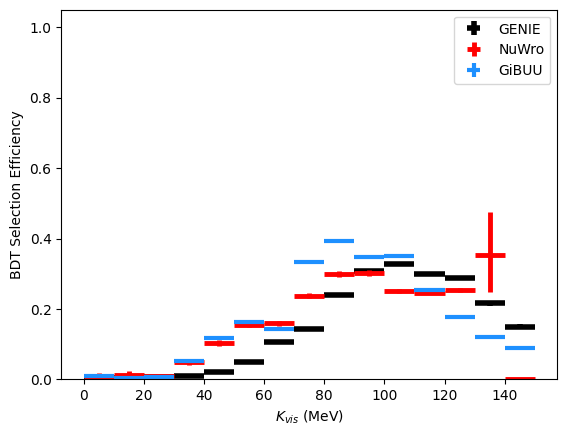

0.30429478585720066


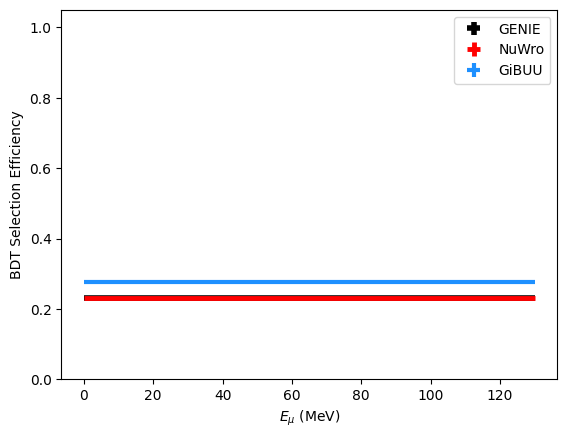

0.9629500389099122


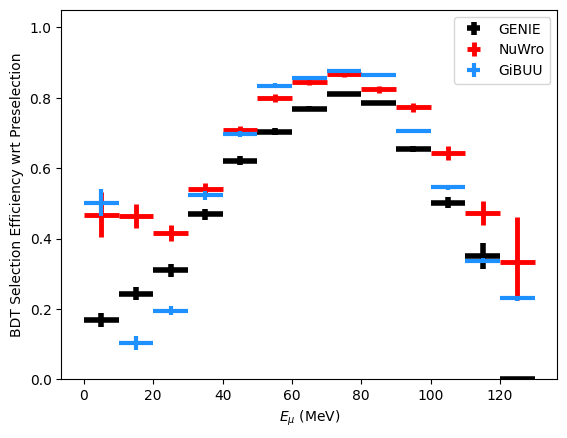

0.8880398671096346


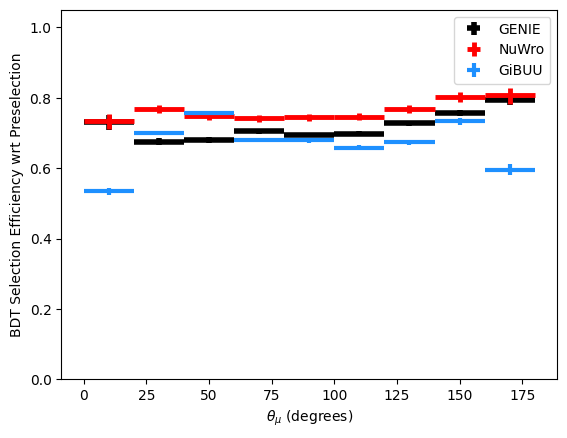

1.0694444298744203


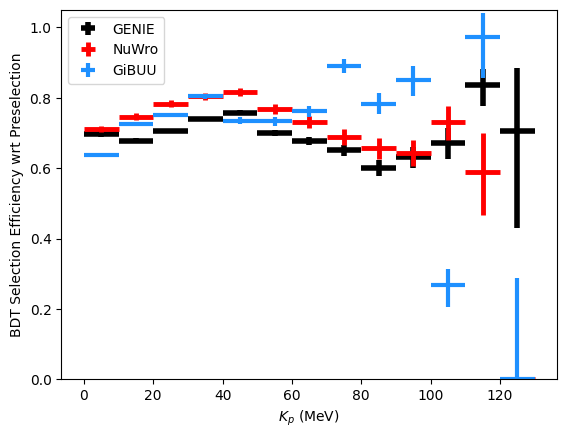

0.8987746477127075


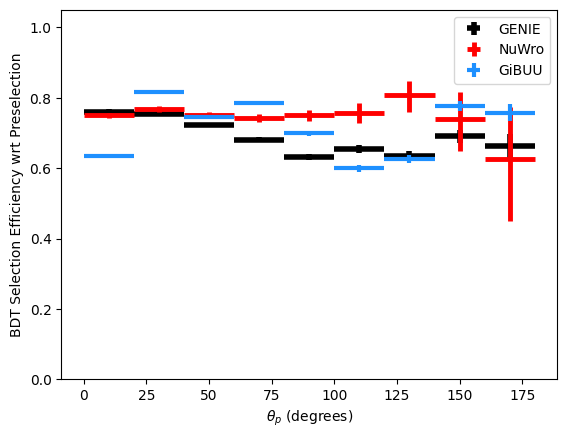

0.962785142660141


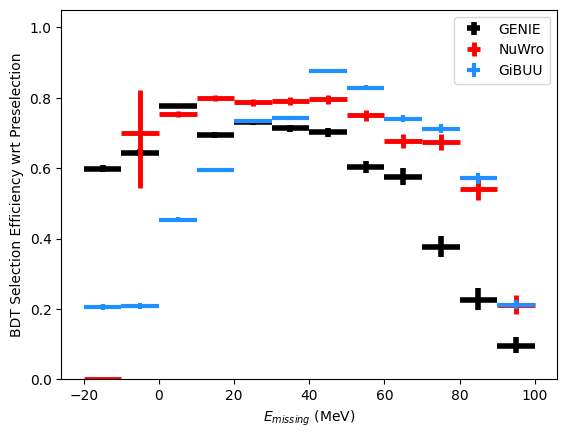

1.1


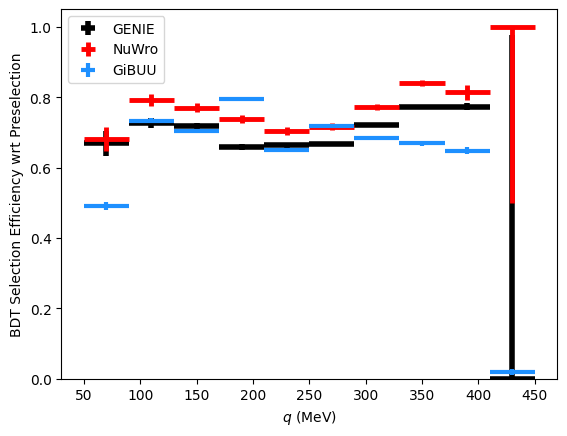

0.9261954261954263


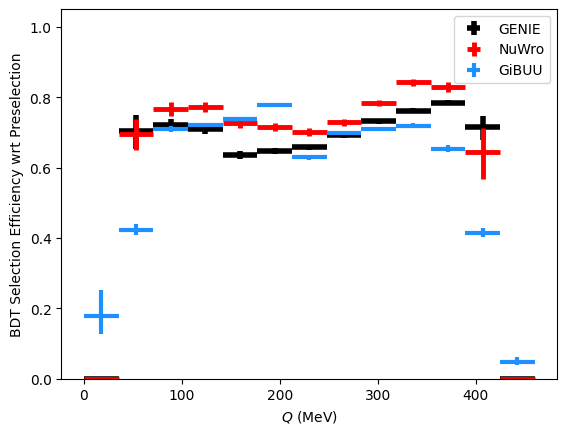

0.9612900614738465


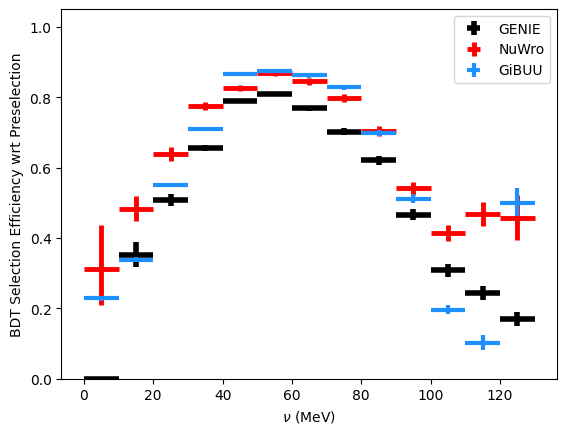

0.9452095808383234


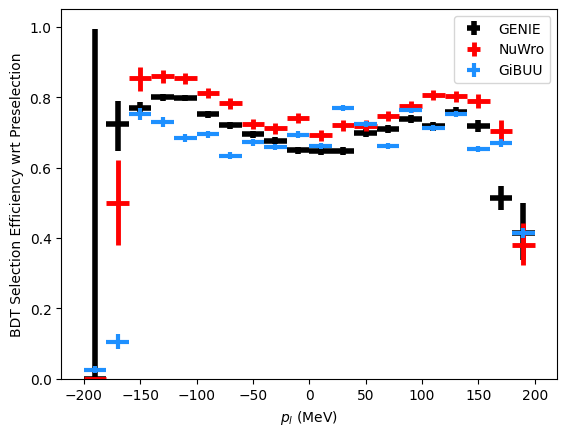

0.8988785958069235


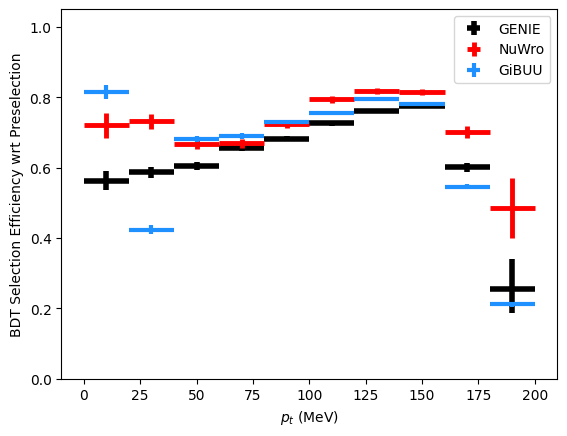

1.1


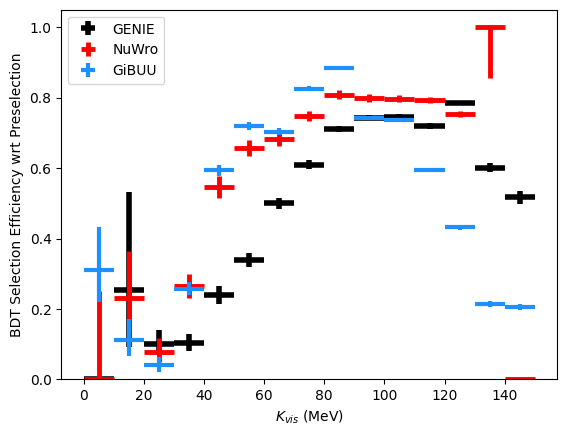

0.8310156250000001


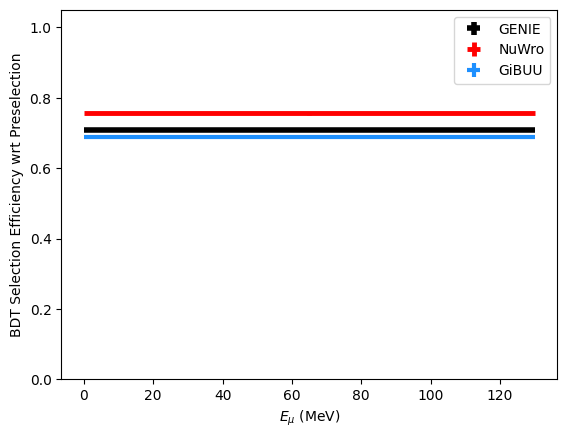

In [37]:

plot_efficiency_detailed(this_bdt_var,this_cutvalue)
plot_efficiency_detailed(this_bdt_var,this_cutvalue,wrt_preset=True)


In [38]:

if(1): 
    save_bdt(model_lowE,"model_lowE","_777")
    
    model_dump = model_lowE.get_dump()
    kdar.convert_model(model_dump, input_variables=kdar.train_vars_nokineprim_tvma, output_xml= "model_lowE_777.xml")


In [40]:

train_vars = []
train_vars = kdar.train_vars_nokineprim

fraction = 0.6
num_vars = 500
n = 200
num_classes=2

train_df  = pd.concat([train_kdar_df, train_overlay_df], sort=False)
test_df  = pd.concat([test_kdar_df, test_overlay_df], sort=False)

# Extract feature and target arrays
X_test, y_test = test_df.fillna(0)[train_vars].copy(), test_df[['is_KDAR']].copy()
X_train, y_train = train_df.fillna(0)[train_vars].copy(), train_df[['is_KDAR']].copy()
    
presel_model_hiE_genie_only = SelectKBest(f_classif, k=num_vars).fit(X_train, y_train)
new_names_hiE_genie_only = list(presel_model_hiE_genie_only.get_feature_names_out())

X_train = presel_model_hiE_genie_only.transform(X_train)
X_test = presel_model_hiE_genie_only.transform(X_test)

# Define the hyperparameter distributions
param_dist = {
    'max_depth': stats.randint(3, 10),
    'eta': stats.uniform(0, 1),
    'gamma':stats.uniform(2, 30),
    'lambda':stats.uniform(0, 10),
    'alpha':stats.uniform(0, 10),
    'min_child_weight':stats.uniform(0, 10),
     'colsample_bytree': stats.uniform(0.5, 0.5),
     'colsample_bylevel': stats.uniform(0.5, 0.5)
}

# Create the XGBoost model object
xgb_model_hiE_genie_only = xgb.XGBClassifier(random_state=777)

# Create the RandomizedSearchCV object
random_search_hiE_genie_only = RandomizedSearchCV(xgb_model_hiE_genie_only, param_distributions=param_dist, n_iter=100, cv=5, scoring='roc_auc',random_state=777)

# Fit the RandomizedSearchCV object to the training data
random_search_hiE_genie_only.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", random_search_hiE_genie_only.best_params_)
print("Best score: ", random_search_hiE_genie_only.best_score_)

new_params_hiE_genie_only = random_search_hiE_genie_only.best_params_
new_params_hiE_genie_only["objective"] =  "binary:logistic"
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True,feature_names=new_names_hiE_genie_only)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True,feature_names=new_names_hiE_genie_only)
evals = [(dtest_reg, "validation"), (dtrain_reg, "train")]
evals_result_hiE_genie_only = {}
model_hiE_genie_only = xgb.train(
   params=random_search_hiE_genie_only.best_params_,
   dtrain=dtrain_reg,
   num_boost_round=n,
   evals=evals,
   verbose_eval=200,
    evals_result=evals_result_hiE_genie_only
)


/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=500 is greater than n_features=319. All the features will be returned.
  warnings.warn(
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [313 314 316 317] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best set of hyperparameters:  {'alpha': 1.0703593984342819, 'colsample_bylevel': 0.7540243170159844, 'colsample_bytree': 0.8288881538504023, 'eta': 0.18031773031070453, 'gamma': 5.723351406528472, 'lambda': 1.8318558970220467, 'max_depth': 9, 'min_child_weight': 0.2133480613728611}
Best score:  0.9340277248433966
[0]	validation-logloss:0.41459	train-logloss:0.53239
[199]	validation-logloss:0.22385	train-logloss:0.21386


In [41]:

assign_bdt_vars(model_hiE_genie_only,new_names_hiE_genie_only,"kdar_score_hiE_genie_only")


[0.99197316 0.98095554 0.9815591  ... 0.1807516  0.10367773 0.1807516 ]


/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  kdar_overlay_df[bdt_var] = d_pred
/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_kdar_df[bdt_var] = d_pred
/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

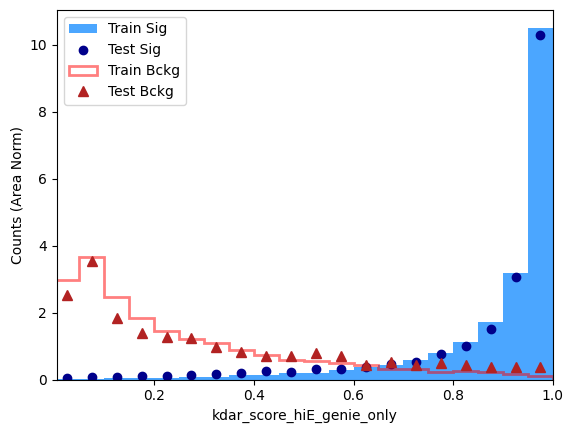

[2.51861907 3.54773224 1.90927575 1.42180109 1.2728505  1.34055531
 0.90724451 0.83953969 0.70413006 0.6905891  0.75829391 0.73121199
 0.46039273 0.55517947 0.36560599 0.48747466 0.39268792 0.36560599
 0.35206503 0.37914696]


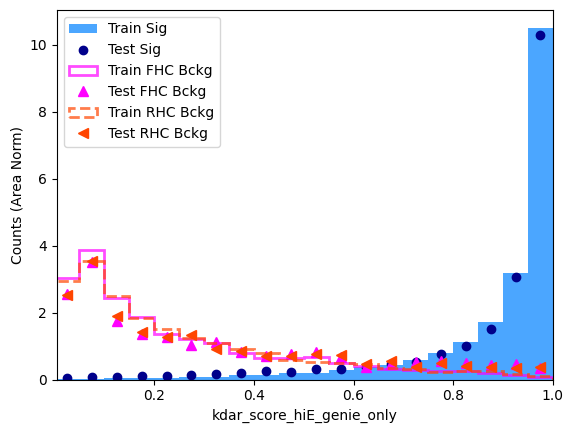

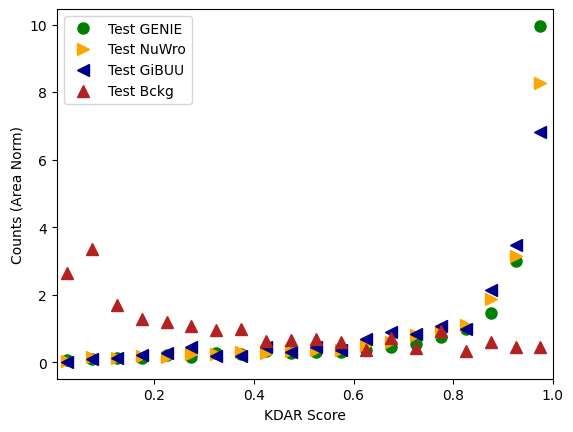

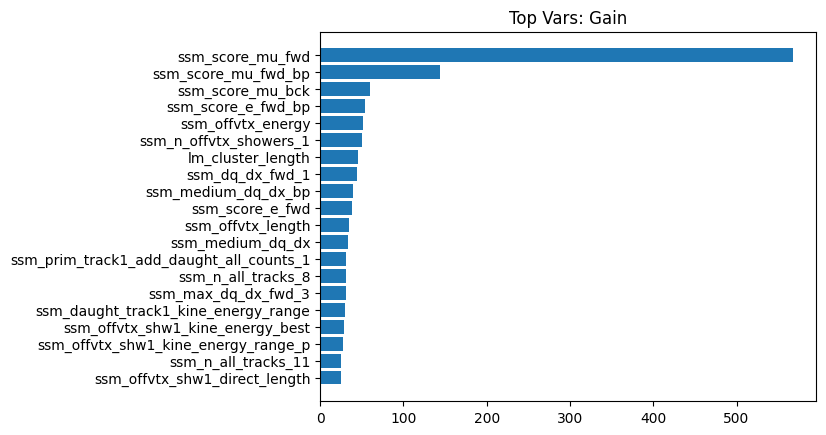

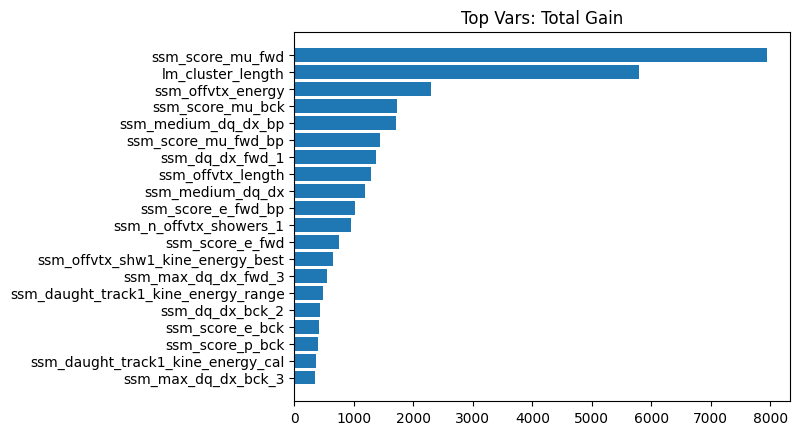

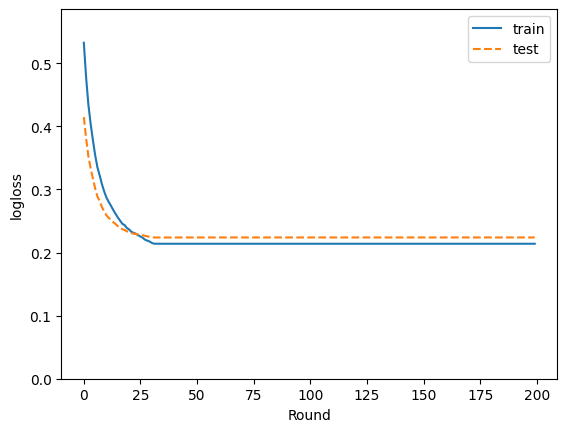

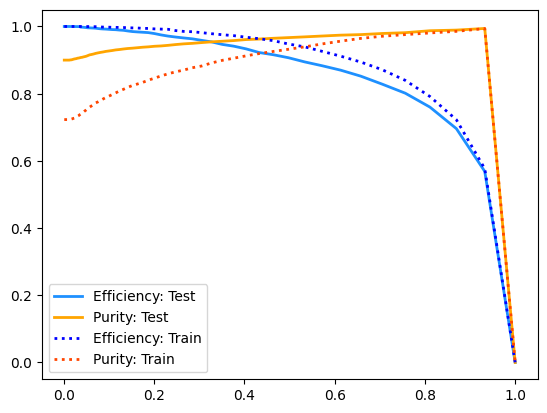

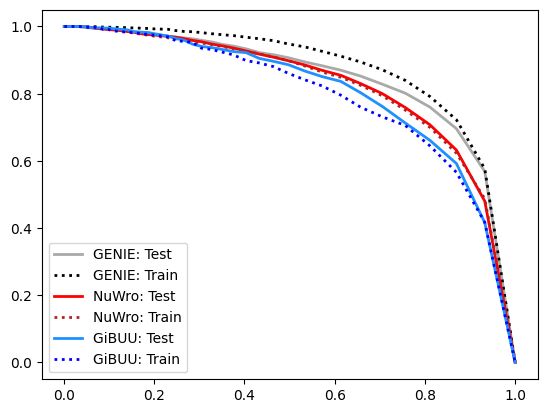

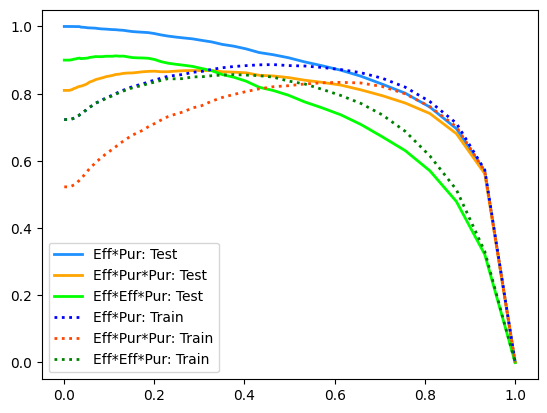

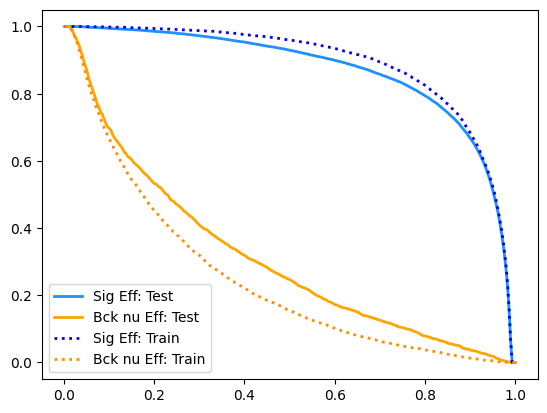

In [42]:

evaluate_BDT(model_hiE_genie_only,"kdar_score_hiE_genie_only",evals_result_hiE_genie_only,max_items=20)


In [43]:

this_cutvalue = 0.85
this_bdt_var = "kdar_score_hiE_genie_only"

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Train BDT lowE passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT lowE passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("Train BDT hiE passrate:",round(np.sum(train_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))
print("Test BDT hiE passrate:",round(np.sum(test_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))



old gen sel lowE passrate: 0.235
gen sel lowE passrate: 0.263
pre sel lowE passrate: 0.094
Train BDT lowE passrate: 0.033
Test BDT lowE passrate: 0.034

old gen sel hiE passrate: 0.308
gen sel hiE passrate: 0.316
pre sel hiE passrate: 0.01
Train BDT hiE passrate: 0.0003
Test BDT hiE passrate: 0.0007


In [44]:

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE rel passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT lowE rel passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy()),3))
print("Test BDT lowE rel passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE rel passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT hiE rel passrate:",round(np.sum(train_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT hiE rel passrate:",round(np.sum(test_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy()),3))



old gen sel lowE passrate: 0.235
gen sel lowE passrate: 0.263
pre sel lowE rel passrate: 0.356
Train BDT lowE rel passrate: 0.353
Test BDT lowE rel passrate: 0.358

old gen sel hiE passrate: 0.308
gen sel hiE passrate: 0.316
pre sel hiE rel passrate: 0.031
Train BDT hiE rel passrate: 0.032
Test BDT hiE rel passrate: 0.076


0.4932877868413926


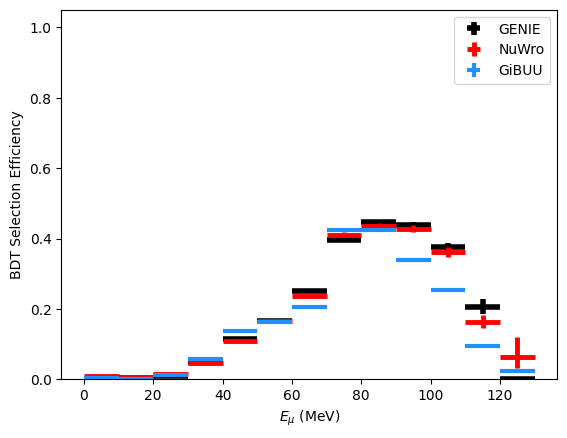

0.35666403174400335


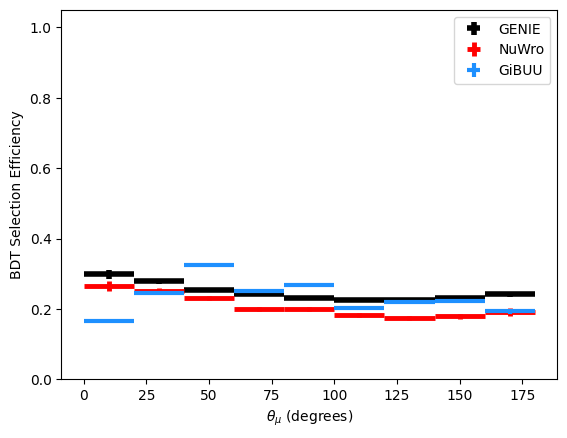

0.3739726027397261


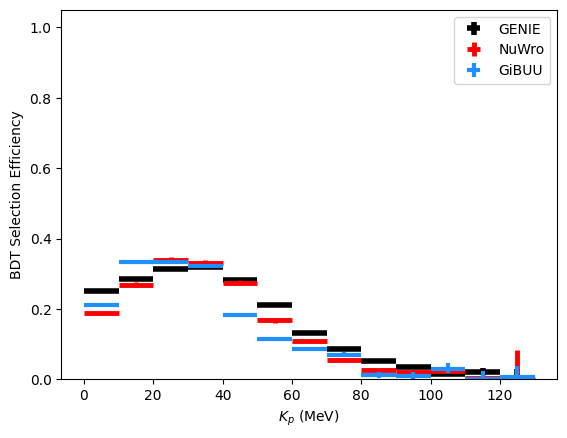

0.4250003814697266


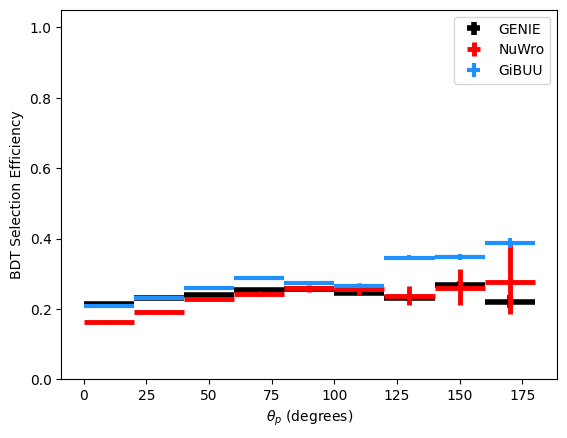

0.41904761904761906


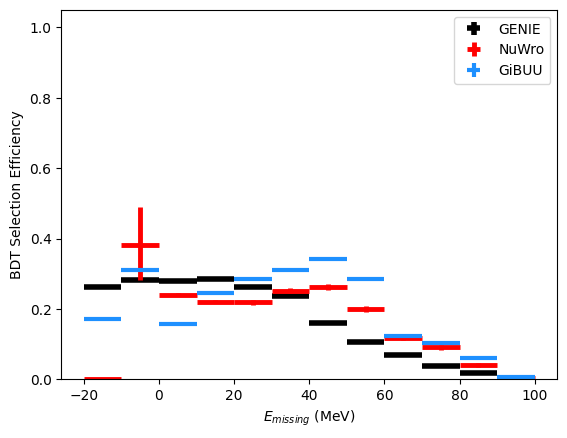

1.1


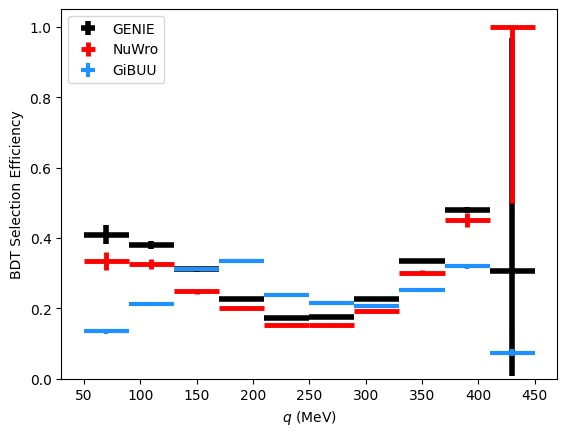

0.5485913336277009


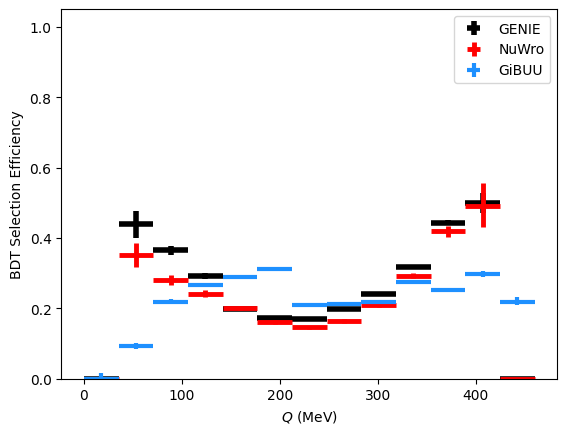

0.4938939362764359


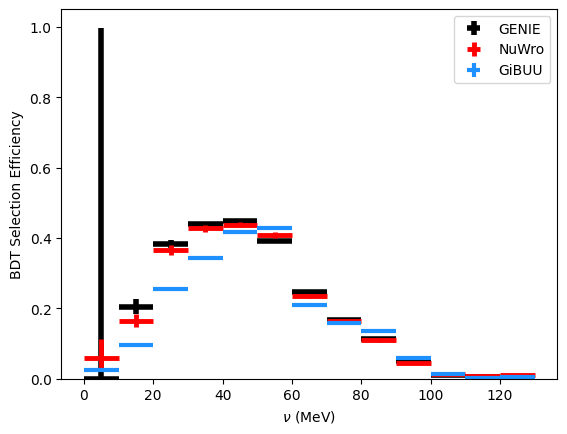

0.5558510638297873


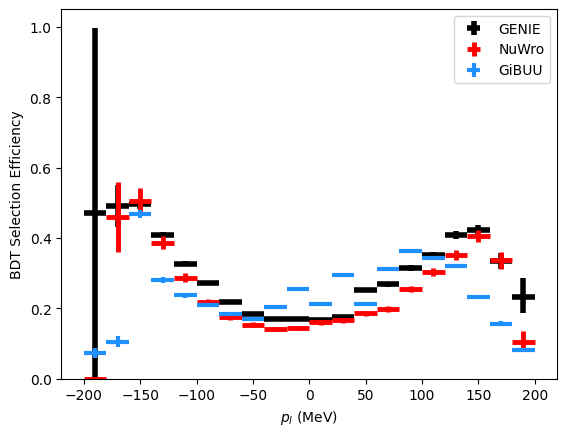

0.4664300736067298


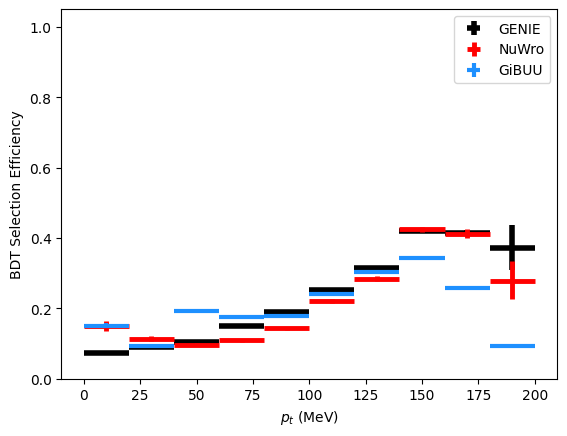

0.38770652115345006


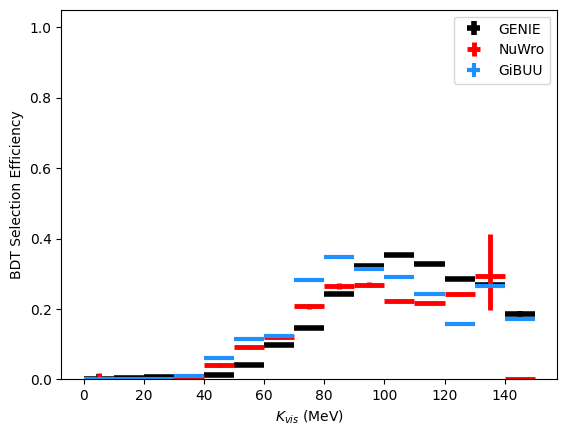

0.2678742527961731


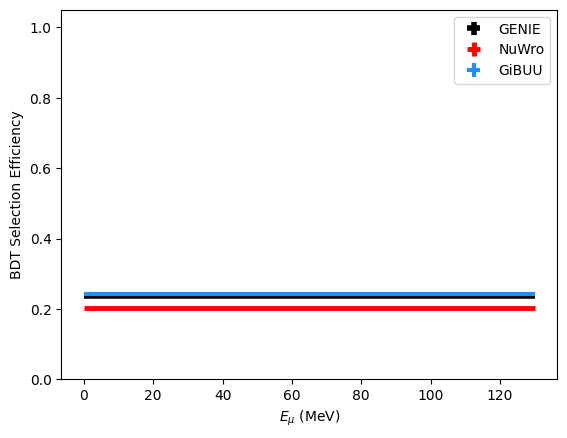

0.9258830666542054


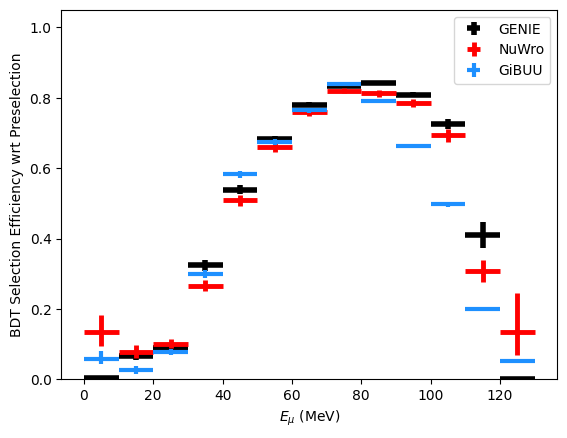

0.8621677458286287


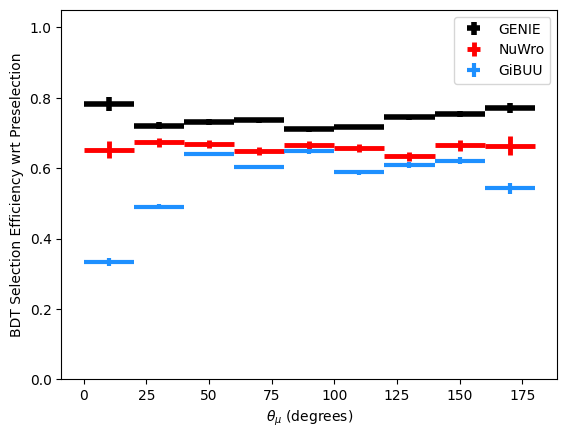

0.9062576591968537


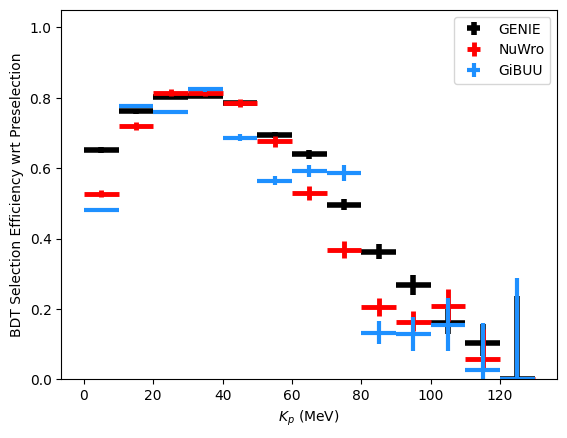

0.9295239627361298


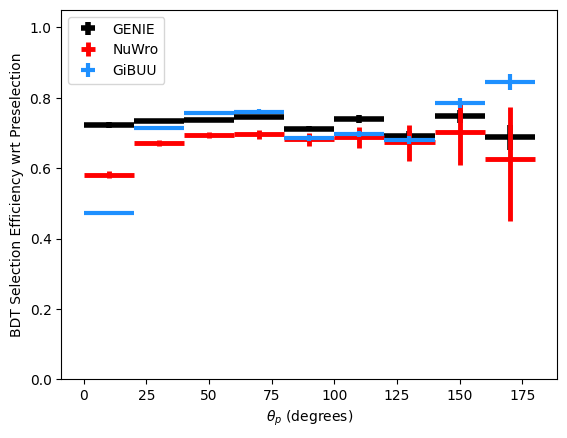

0.8800000000000001


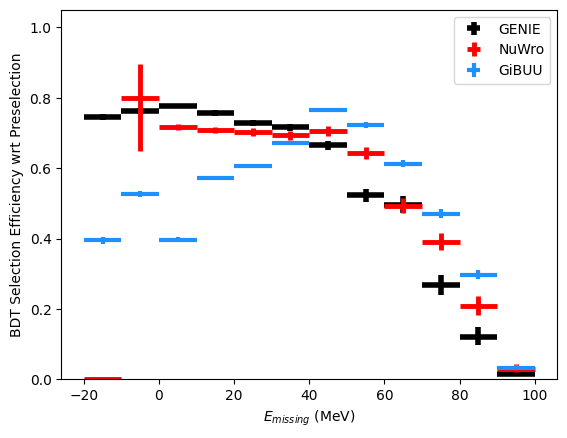

1.1


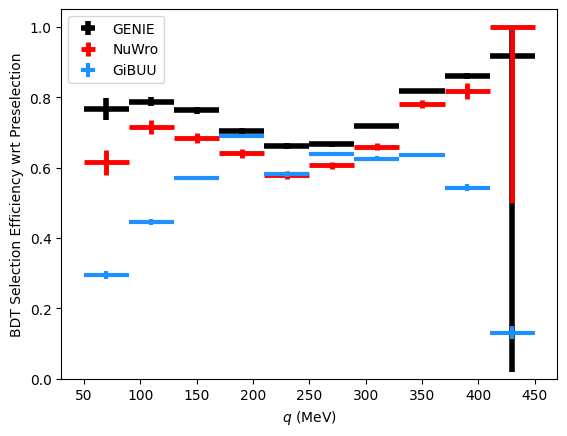

0.9411582291126251


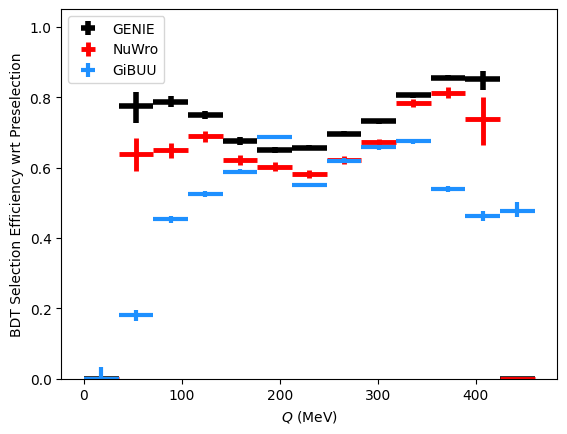

0.9284543335437775


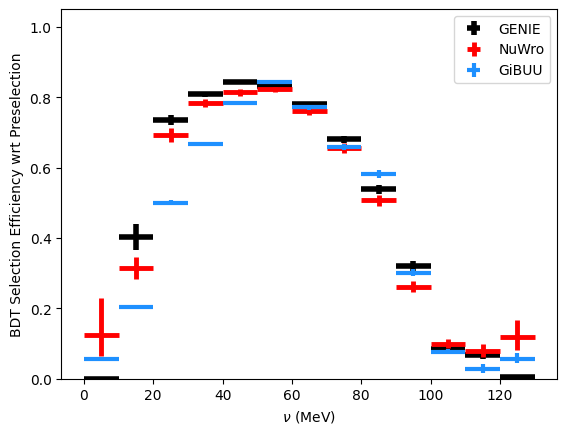

1.1


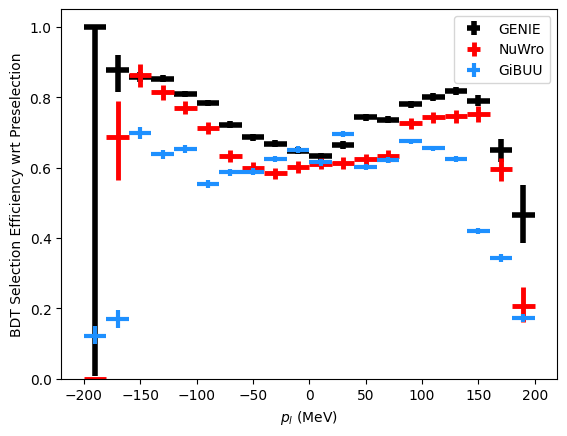

0.9118202686309815


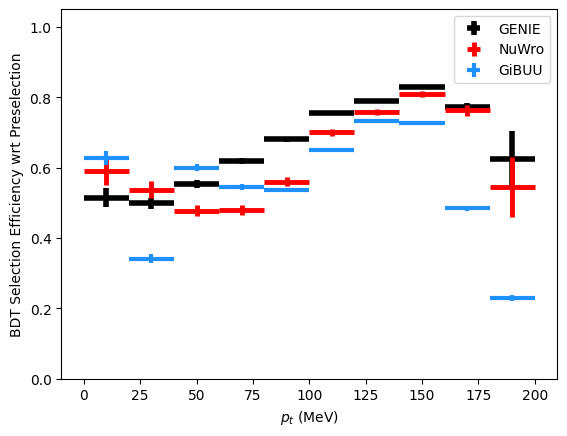

0.9166666666666667


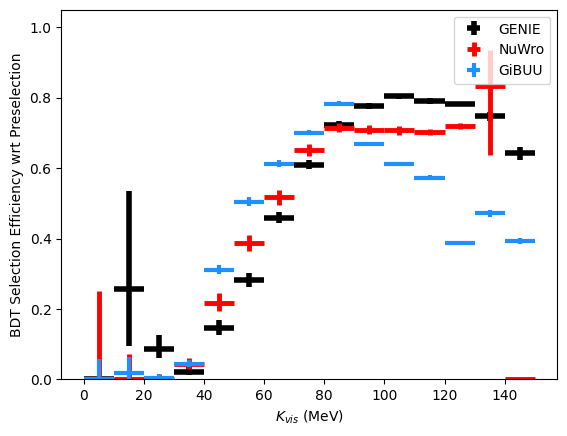

0.8047097623348237


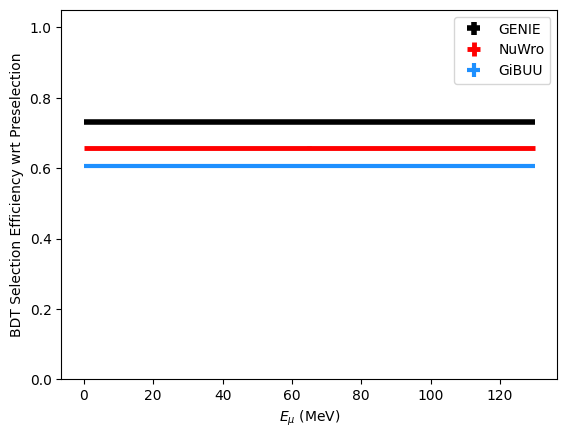

In [45]:

plot_efficiency_detailed(this_bdt_var,this_cutvalue)
plot_efficiency_detailed(this_bdt_var,this_cutvalue,wrt_preset=True)


In [46]:
if(1): 
    save_bdt(model_hiE_genie_only,"model_hiE_genie_only","_777")
    
    model_dump = model_hiE_genie_only.get_dump()
    kdar.convert_model(model_dump, input_variables=kdar.train_vars_nokineprim_tvma, output_xml= "model_hiE_genie_only_777.xml")

In [47]:

train_vars = []
train_vars = kdar.train_vars_nokineprim.copy()

fraction = 0.6
num_vars = 500
n = 200
num_classes=2

train_df  = pd.concat([train_kdar_df,train_nuwro_df,train_gibuu_df, train_overlay_df], sort=False)
test_df  = pd.concat([test_kdar_df,test_nuwro_df,test_gibuu_df, test_overlay_df], sort=False)

# Extract feature and target arrays
X_test, y_test = test_df.fillna(0)[train_vars].copy(), test_df[['is_KDAR']].copy()
X_train, y_train = train_df.fillna(0)[train_vars].copy(), train_df[['is_KDAR']].copy()
    
presel_model_hiE = SelectKBest(f_classif, k=num_vars).fit(X_train, y_train)
new_names_hiE = list(presel_model_hiE.get_feature_names_out())

X_train = presel_model_hiE.transform(X_train)
X_test = presel_model_hiE.transform(X_test)

# Define the hyperparameter distributions
param_dist = {
    'max_depth': stats.randint(3, 10),
    'eta': stats.uniform(0, 1),
    'gamma':stats.uniform(2, 30),
    'lambda':stats.uniform(0, 10),
    'alpha':stats.uniform(0, 10),
    'min_child_weight':stats.uniform(0, 10),
     'colsample_bytree': stats.uniform(0.5, 0.5),
     'colsample_bylevel': stats.uniform(0.5, 0.5)
}

# Create the XGBoost model object
xgb_model_hiE = xgb.XGBClassifier(random_state=777)

# Create the RandomizedSearchCV object
random_search_hiE = RandomizedSearchCV(xgb_model_hiE, param_distributions=param_dist, n_iter=100, cv=5, scoring='roc_auc',random_state=777)

# Fit the RandomizedSearchCV object to the training data
random_search_hiE.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", random_search_hiE.best_params_)
print("Best score: ", random_search_hiE.best_score_)

new_params_hiE = random_search_hiE.best_params_
new_params_hiE["objective"] =  "binary:logistic"
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True,feature_names=new_names_hiE)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True,feature_names=new_names_hiE)
evals = [(dtest_reg, "validation"), (dtrain_reg, "train")]
evals_result_hiE = {}
model_hiE = xgb.train(
   params=random_search_hiE.best_params_,
   dtrain=dtrain_reg,
   num_boost_round=n,
   evals=evals,
   verbose_eval=200,
    evals_result=evals_result_hiE
)


/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=500 is greater than n_features=319. All the features will be returned.
  warnings.warn(
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [313 314 316 317] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/bbogart/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best set of hyperparameters:  {'alpha': 1.0703593984342819, 'colsample_bylevel': 0.7540243170159844, 'colsample_bytree': 0.8288881538504023, 'eta': 0.18031773031070453, 'gamma': 5.723351406528472, 'lambda': 1.8318558970220467, 'max_depth': 9, 'min_child_weight': 0.2133480613728611}
Best score:  0.9252106963780257
[0]	validation-logloss:0.29345	train-logloss:0.44248
[199]	validation-logloss:0.16648	train-logloss:0.18866


In [48]:

assign_bdt_vars(model_hiE,new_names_hiE,"kdar_score_hiE")


[0.99347794 0.98895043 0.9482307  ... 0.59802926 0.74732244 0.59802926]


/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  kdar_overlay_df[bdt_var] = d_pred
/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_kdar_df[bdt_var] = d_pred
/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_47363/1669569469.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

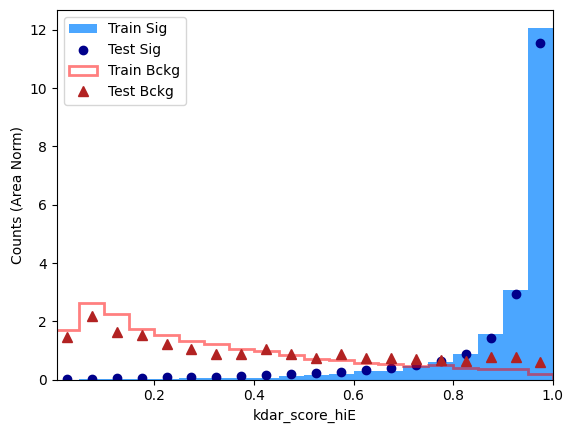

[1.54366975 2.15301308 1.69262035 1.65199746 1.23222761 1.00203124
 0.81245777 0.94786739 0.98849028 0.88016258 0.6905891  0.71767103
 0.74475295 0.75829391 0.71767103 0.67704814 0.6905891  0.75829391
 0.7989168  0.54163851]


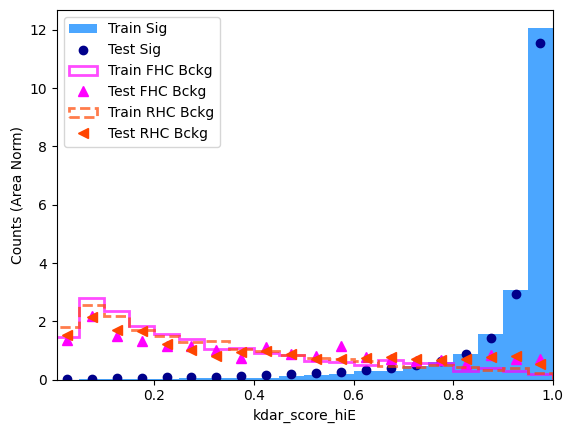

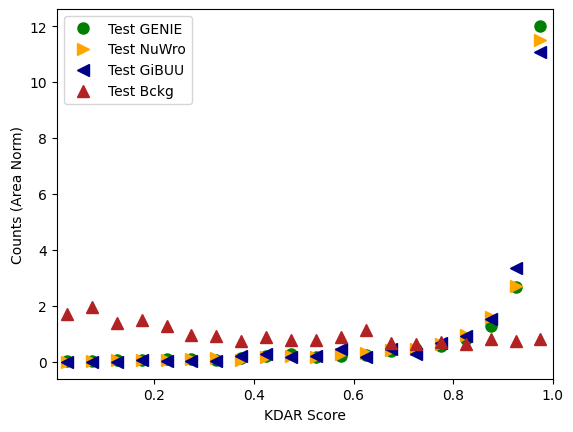

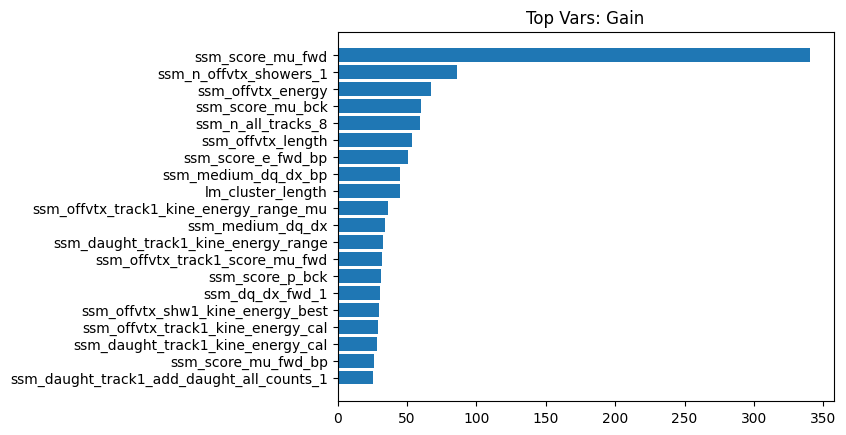

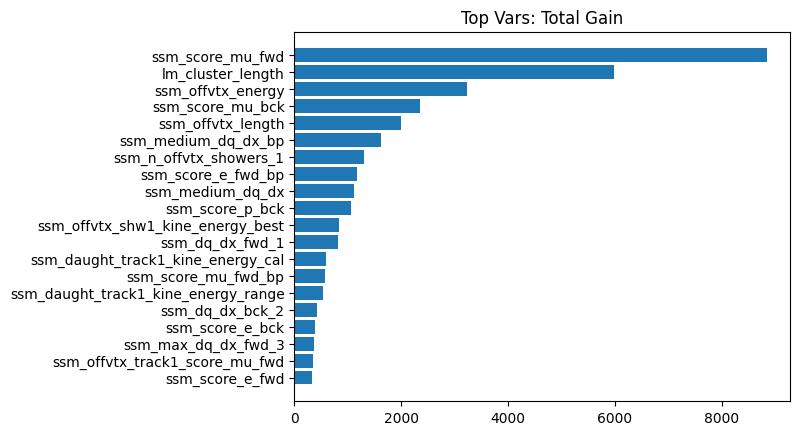

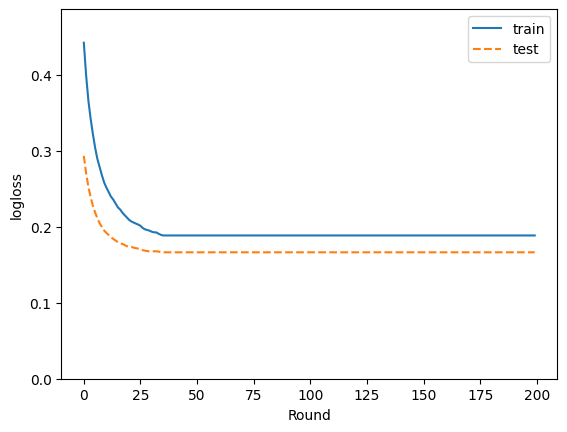

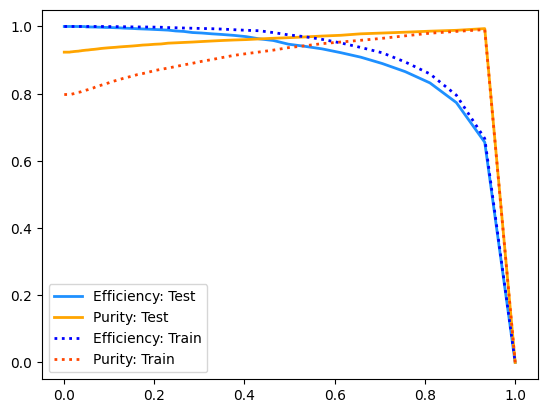

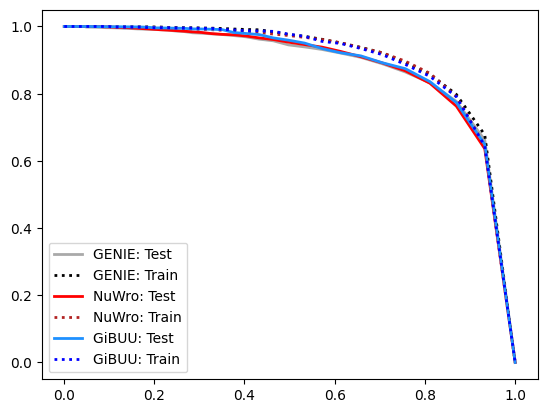

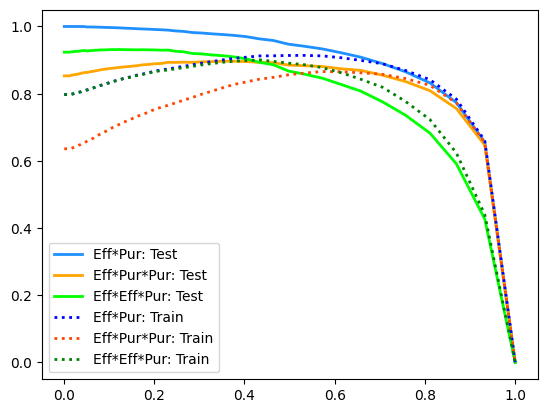

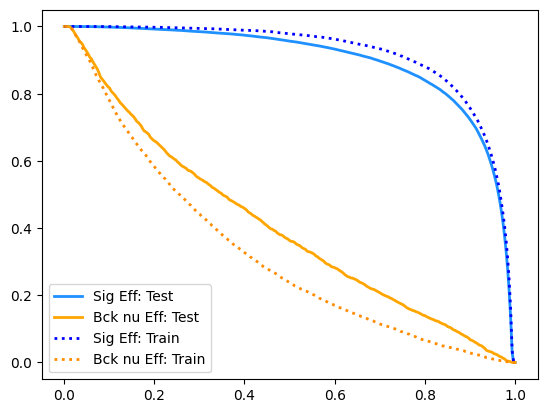

In [49]:

evaluate_BDT(model_hiE,"kdar_score_hiE",evals_result_hiE,max_items=20)


In [50]:

this_cutvalue = 0.9
this_bdt_var = "kdar_score_hiE"

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Train BDT lowE passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT lowE passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("Train BDT hiE passrate:",round(np.sum(train_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))
print("Test BDT hiE passrate:",round(np.sum(test_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))



old gen sel lowE passrate: 0.235
gen sel lowE passrate: 0.263
pre sel lowE passrate: 0.094
Train BDT lowE passrate: 0.035
Test BDT lowE passrate: 0.034

old gen sel hiE passrate: 0.308
gen sel hiE passrate: 0.316
pre sel hiE passrate: 0.01
Train BDT hiE passrate: 0.0003
Test BDT hiE passrate: 0.0007


In [51]:

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE rel passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT lowE rel passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy()),3))
print("Test BDT lowE rel passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE rel passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT hiE rel passrate:",round(np.sum(train_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT hiE rel passrate:",round(np.sum(test_overlay_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy()),3))



old gen sel lowE passrate: 0.235
gen sel lowE passrate: 0.263
pre sel lowE rel passrate: 0.356
Train BDT lowE rel passrate: 0.373
Test BDT lowE rel passrate: 0.368

old gen sel hiE passrate: 0.308
gen sel hiE passrate: 0.316
pre sel hiE rel passrate: 0.031
Train BDT hiE rel passrate: 0.035
Test BDT hiE rel passrate: 0.077


0.4984451354953355


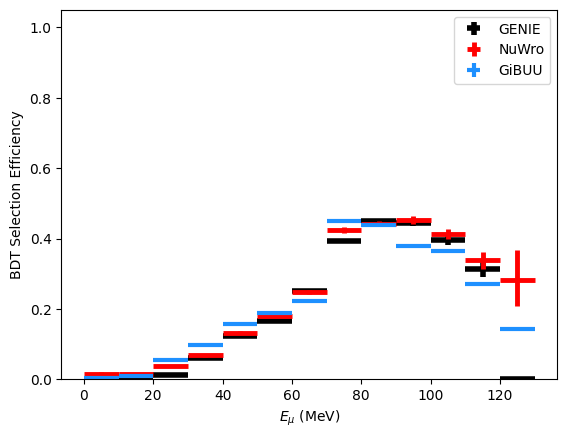

0.44884224832057956


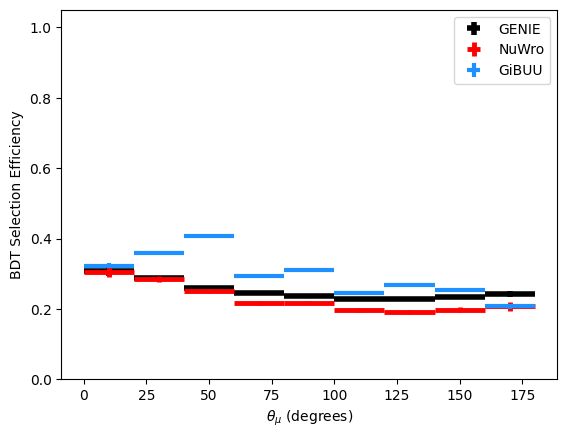

0.38712328767123294


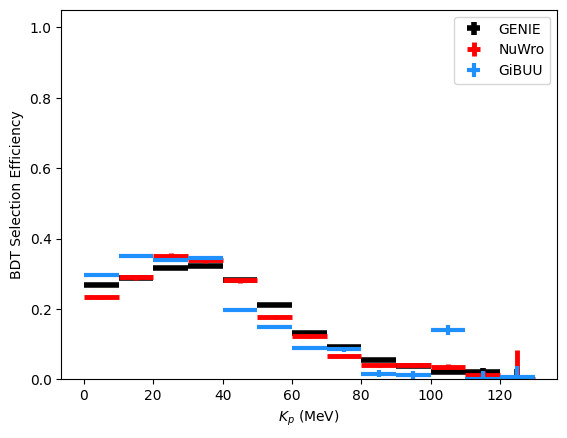

0.44277593493461614


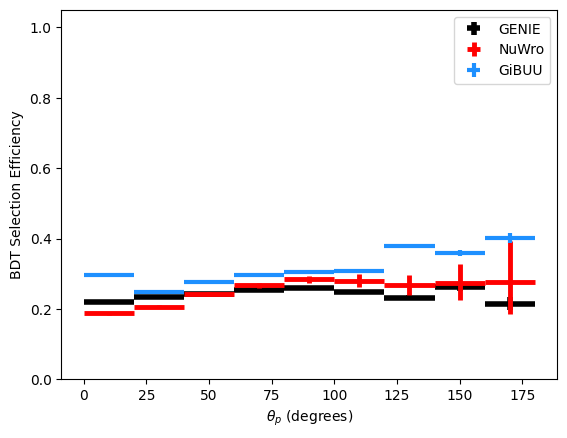

0.41904761904761906


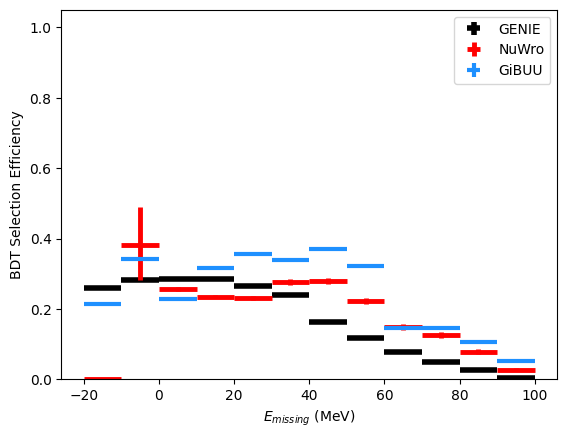

1.1


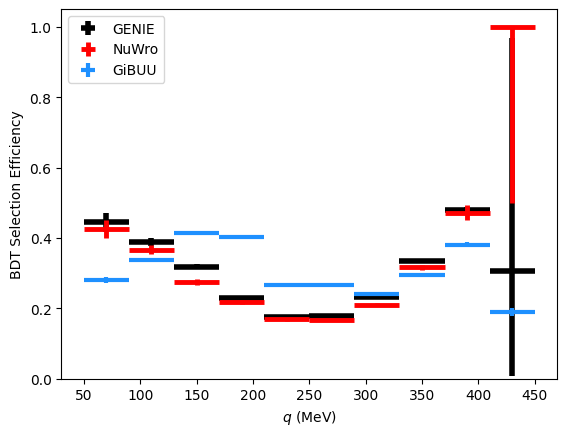

0.5587301587301587


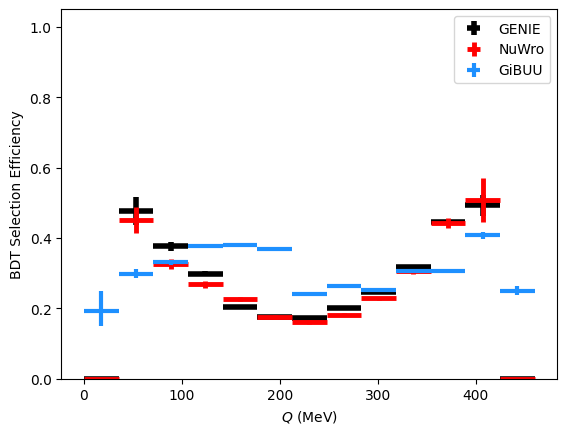

0.49771126760563383


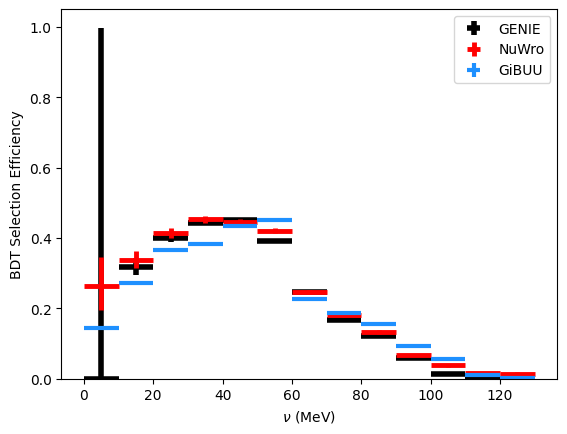

0.5720298111438752


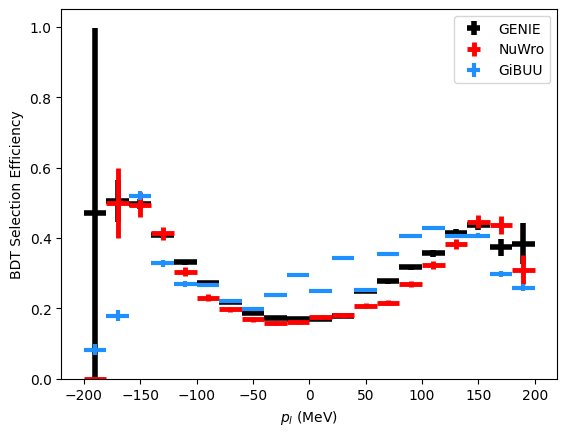

0.482990506329114


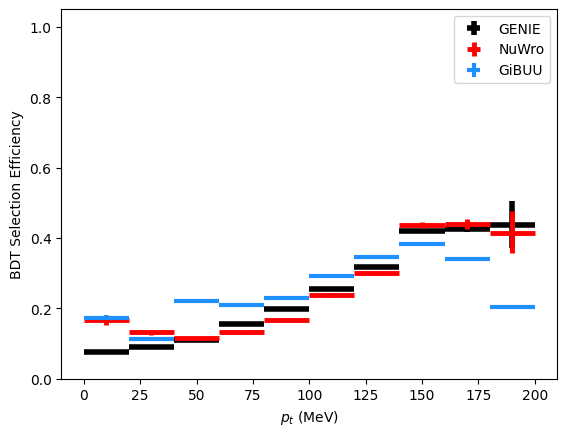

0.40919342041015627


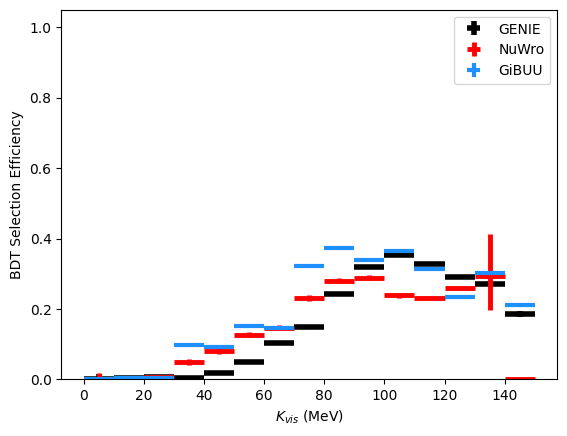

0.3235658794641495


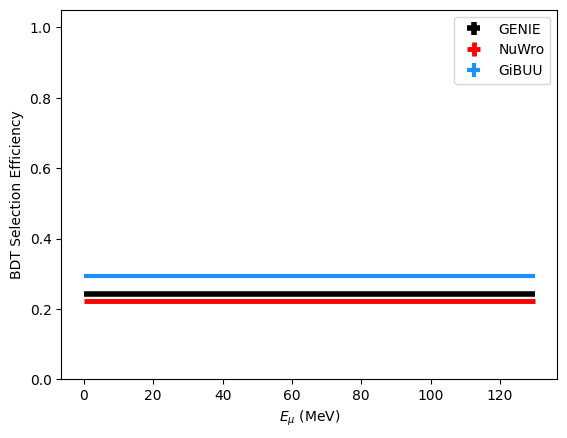

0.9764496982097627


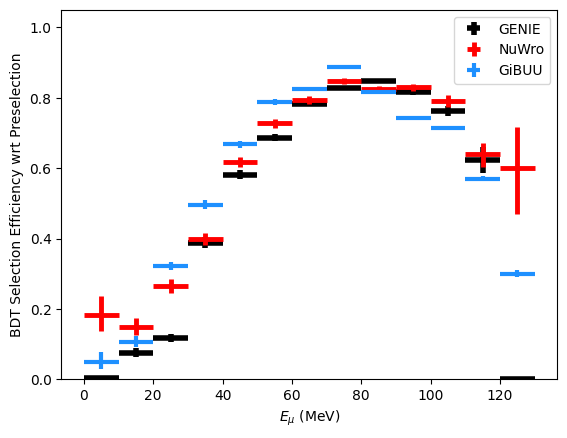

0.8886556565761566


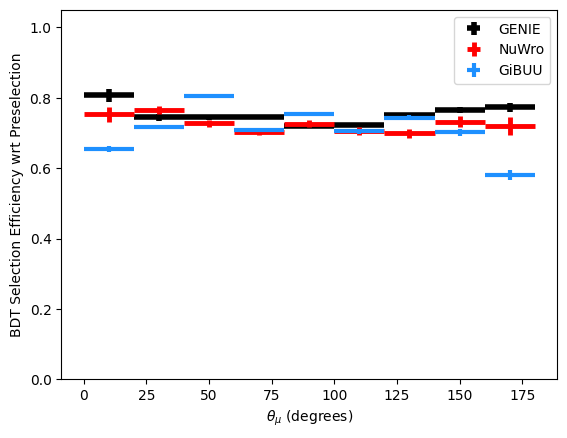

0.9660247147083283


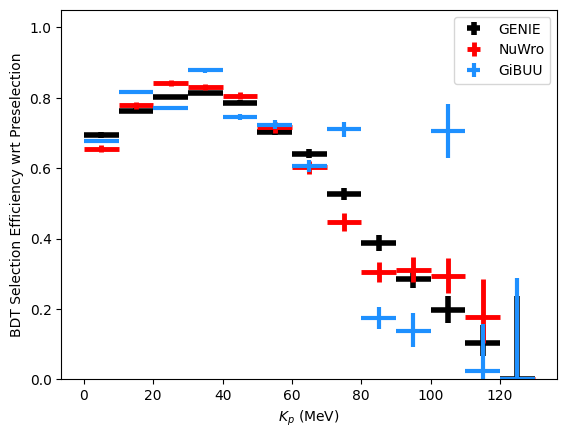

0.9684011876583101


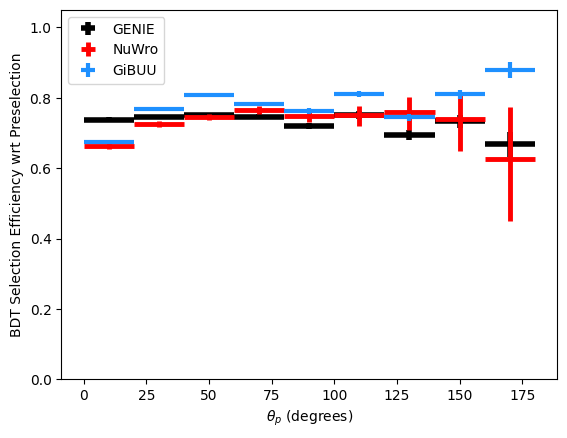

0.9108083367347718


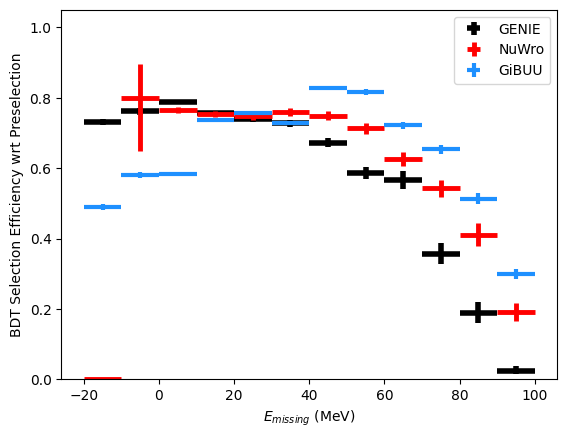

1.1


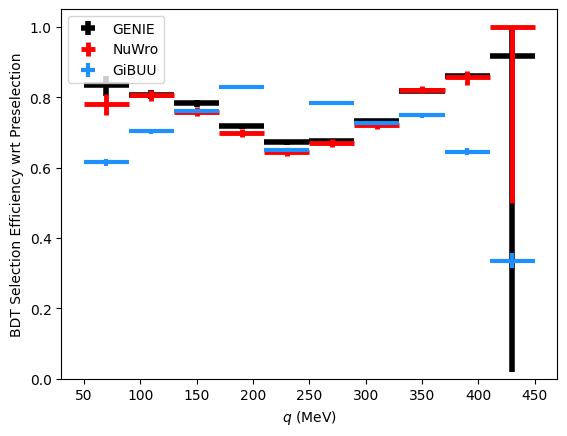

0.9462171052631579


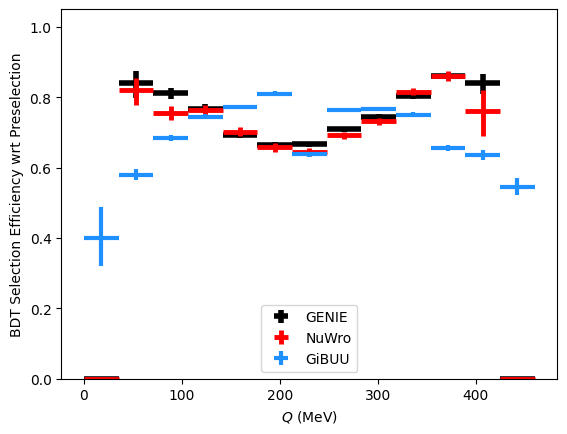

0.9749485194683076


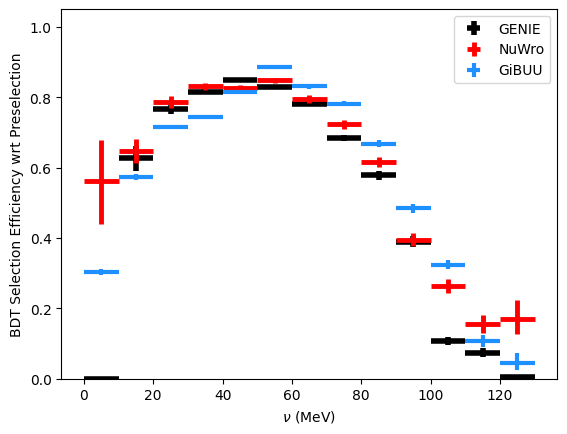

1.1


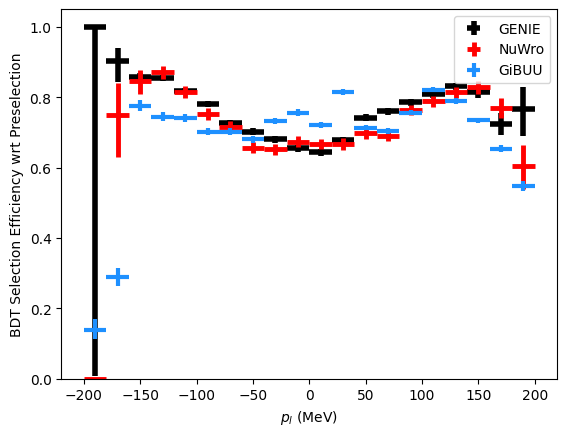

0.9161144578313254


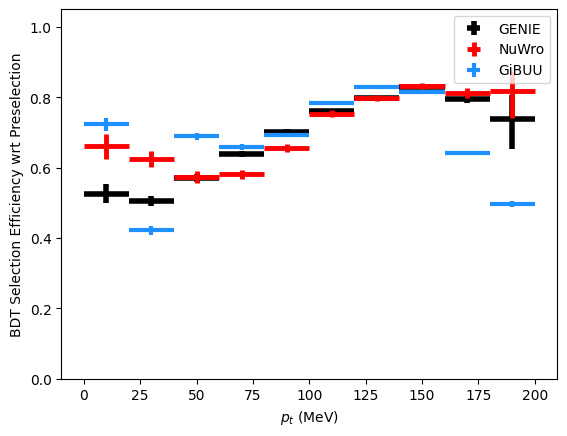

0.924063766002655


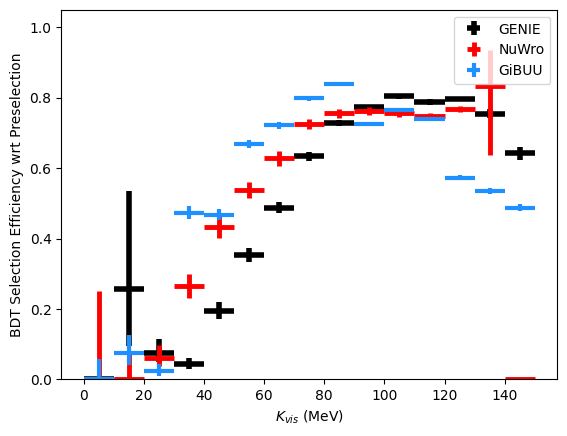

0.815460342168808


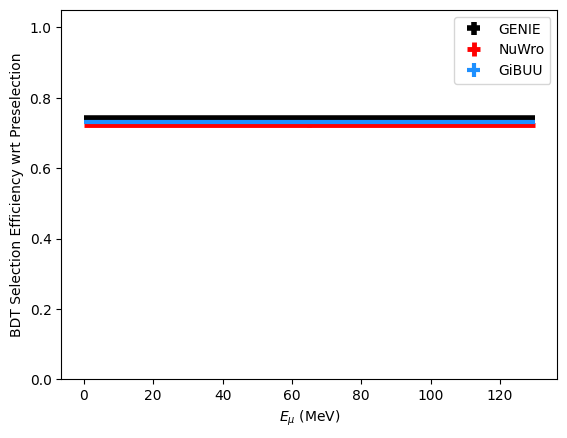

In [52]:

plot_efficiency_detailed(this_bdt_var,this_cutvalue)
plot_efficiency_detailed(this_bdt_var,this_cutvalue,wrt_preset=True)


In [53]:
if(1): 
    save_bdt(model_hiE,"model_hiE","_777")

    model_dump = model_hiE.get_dump()
    kdar.convert_model(model_dump, input_variables=kdar.train_vars_nokineprim_tvma, output_xml= "model_hiE_777.xml")

In [ ]:
this_cutvalue = 0.7
this_bdt_var = "kdar_score_lowE_genie_only"
this_add_cut = "kdar_score_hiE_genie_only>0.8"

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Train BDT lowE passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT lowE passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("Train BDT hiE passrate:",round(np.sum(train_overlay_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))
print("Test BDT hiE passrate:",round(np.sum(test_overlay_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))


In [ ]:

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE rel passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT lowE rel passrate:",round(np.sum(train_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy()),3))
print("Test BDT lowE rel passrate:",round(np.sum(test_lowE_df.query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE rel passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT hiE rel passrate:",round(np.sum(train_overlay_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT hiE rel passrate:",round(np.sum(test_overlay_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy()),3))


In [ ]:


plot_efficiency_detailed(this_bdt_var,this_cutvalue,add_cut = this_add_cut,adjusty=True)
plot_efficiency_detailed(this_bdt_var,this_cutvalue,wrt_preset=True,add_cut = this_add_cut,adjusty=True)



In [ ]:
this_cutvalue = 0.85
this_bdt_var = "kdar_score_lowE"
this_add_cut = "kdar_score_hiE>0.9"

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Train BDT lowE passrate:",round(np.sum(train_lowE_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT lowE passrate:",round(np.sum(test_lowE_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy())*np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("Train BDT hiE passrate:",round(np.sum(train_overlay_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))
print("Test BDT hiE passrate:",round(np.sum(test_overlay_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy())*np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),4))


In [ ]:

print("old gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("gen sel lowE passrate:",round(np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(lowE_overlay_df["net_weight"].to_numpy()),3))
print("pre sel lowE rel passrate:",round(np.sum(lowE_overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(lowE_overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT lowE rel passrate:",round(np.sum(train_lowE_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_lowE_df["net_weight"].to_numpy()),3))
print("Test BDT lowE rel passrate:",round(np.sum(test_lowE_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_lowE_df["net_weight"].to_numpy()),3))

print("")
print("old gen sel hiE passrate:",round(np.sum(overlay_df.query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("gen sel hiE passrate:",round(np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(overlay_df["net_weight"].to_numpy()),3))
print("pre sel hiE rel passrate:",round(np.sum(overlay_df.query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(overlay_df.query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy()),3))
print("Train BDT hiE rel passrate:",round(np.sum(train_overlay_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(train_overlay_df["net_weight"].to_numpy()),3))
print("Test BDT hiE rel passrate:",round(np.sum(test_overlay_df.query(this_add_cut).query(kdar.presel_query).query(this_bdt_var+f">{this_cutvalue}")["net_weight"].to_numpy())/np.sum(test_overlay_df["net_weight"].to_numpy()),3))


In [ ]:

plot_efficiency_detailed(this_bdt_var,this_cutvalue,add_cut = this_add_cut ,adjusty=True)
plot_efficiency_detailed(this_bdt_var,this_cutvalue,wrt_preset=True,add_cut = this_add_cut ,adjusty=True)



In [236]:

p = nuwro_df.query("run==20431 and subrun==22 and event==1111")["kdar_score_lowE"].to_numpy()[0]
print(p)
print(np.log(p/(1-p)) - 0.4876137)
print(np.log(p/(1-p)) - 0.4876137-0.6950436221720979)
      
p = nuwro_df.query("run==19766 and subrun==107 and event==5394")["kdar_score_lowE"].to_numpy()[0]
print(np.log(p/(1-p)))
print(np.log(p/(1-p)) - 1.3879799)
print(np.log(p/(1-p)) - 1.3879799-0.6950436221720979)



0.765425
0.6950423160701813
-1.3061019166205057e-06
2.083023522172098
0.6950436221720979
0.0


In [ ]:
#### p = nuwro_df.query("run==20431 and subrun==22 and event==1111")["kdar_score_hiE"].to_numpy()[0]
print(np.log(p/(1-p)))
print(np.log(p/(1-p)) - 0.6872310)
print(np.log(p/(1-p)) - 0.6872310-1.178174653068278)
      
p = nuwro_df.query("run==19766 and subrun==107 and event==5394")["kdar_score_hiE"].to_numpy()[0]
print(np.log(p/(1-p)))
print(np.log(p/(1-p)) - 3.2054719)
print(np.log(p/(1-p)) - 3.2054719-1.178174653068278)


In [239]:
p = 0.75
print(np.log(p/(1-p)) + 0.6950436221720979)
p = 0.88
print(np.log(p/(1-p)) + 1.178174653068278)

1.7936559108402077
3.170604817758484


In [240]:
p = 0.75
print(np.log(p/(1-p)) - 0.6950436221720979)
p = 0.88
print(np.log(p/(1-p)) - 1.178174653068278)

0.40356866649601186
0.8142555116219283


In [245]:
p = 0.78
print(np.log(p/(1-p)) - 0.6950436221720979)
p = 0.9
print(np.log(p/(1-p)) - 1.178174653068278)

0.5706227511591782
1.0190499242679416
